<p align="center">
<img src="Images/sorbonne_logo.png" alt="Logo" width="300"/>
</p>

# **Module 3 - AR Analysis**

* **Author**: Elia Landini
* **Student ID**: 12310239
* **Course**: EESM2-Financial Economics 
* **Supervisor**: Jean-Bernard Chatelain
* **Reference Repository**: https://github.com/EliaLand/Policy_Target_RegimeSwitchingPersistence

### **1) REQUIREMENTS SET-UP**

In [716]:
# Requirements.txt file installation
# !pip install -r requirements.txt

In [717]:
# Libraries import
import warnings
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
import plotly.graph_objects as go
%matplotlib inline
from itertools import combinations
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import levene
from scipy.stats import ks_2samp
from scipy.stats import kstest
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from statsmodels.tsa.stattools import pacf
import sklearn.tree
import sklearn.metrics
import sklearn.metrics
import sklearn.model_selection
import sklearn.preprocessing 
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, precision_recall_curve, auc, 
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.linear_model import (LinearRegression, LogisticRegression)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
import plotly.express as px
import openpyxl as pxl
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML
from IPython.display import Image
import itertools
from arch.unitroot import PhillipsPerron

### **2) OVERTIME PLOTTING**

In [718]:
# df import
jp_aggregated_df = pd.read_csv("Data/Aggregated/jp_aggregated_df.csv")
jp_trans_df = pd.read_csv("Data/Transformed/jp_trans_df.csv")
jp_core_trans_df = pd.read_csv("Data/Transformed/jp_core_trans_df.csv")
jp_core_hybrid_df = pd.read_csv("Data/Transformed/jp_core_hybrid_df.csv")

In [719]:
# General color settings (viridis palette)
core_trans_var_colors = {
    "LogDiff-HICP (SA)": "#1F9E89",  
    "AR(1)detrend-Call Money/Interbank Immediate (%)":       "#440154",  
    "AR(1)detrend-10-Year Gov Bond Yields (%)":       "#FDE725" 
}

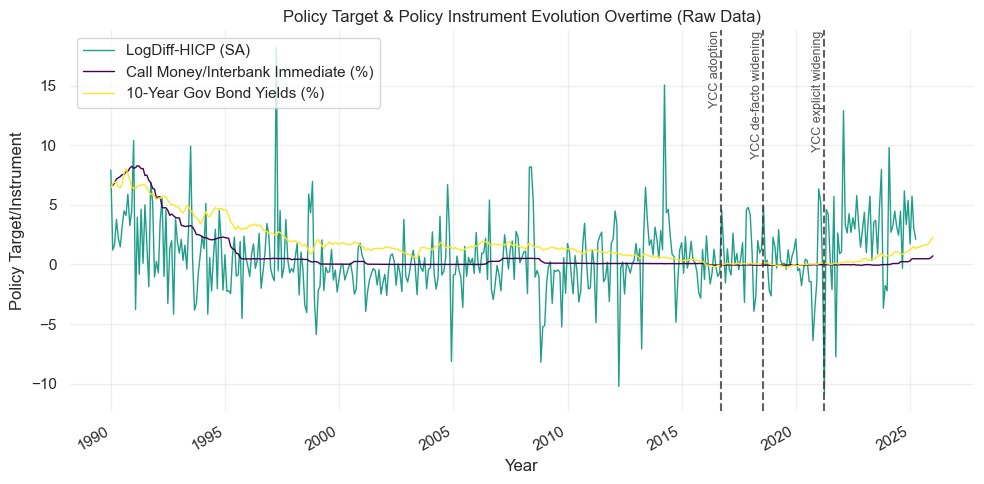

In [720]:
# Over time plotting (Raw Data): Policy Target (LogDiff-HICP (SA)) and Policy Instrument (Call Money/Interbank Immediate (%), 10-Year Gov Bond Yields (%)) 

fig, ax = plt.subplots(figsize=(10, 5))

# Index settings for the 2 datasets (jp_aggregated_df and jp_core_trans_df)
# (!!!) We also restrict the sample to observations later than 01/01/1990
jp_core_trans_df = jp_core_trans_df.reset_index()
jp_core_trans_df["Time"] = pd.to_datetime(jp_core_trans_df["Time"]) 
jp_core_trans_df = jp_core_trans_df.set_index("Time")
df1 = jp_core_trans_df.copy()
df1 = df1[df1.index >= "1990-01-01"]

jp_aggregated_df = jp_aggregated_df.reset_index()
jp_aggregated_df["Time"] = pd.to_datetime(jp_aggregated_df["Time"]) 
jp_aggregated_df = jp_aggregated_df.set_index("Time")
df2 = jp_aggregated_df.copy()
df2 = df2[df2.index >= "1990-01-01"]

# Plot set-up 
# (!!!) Separate plotting for raw and transformed variables
ax.plot(
    df1.index,
    df1["LogDiff-HICP (SA)"],
    label="LogDiff-HICP (SA)",
    linewidth=1,
    color = "#1F9E89"
    )

ax.plot(
    df2.index,
    df2["Call Money/Interbank Immediate (%)"],
    label= "Call Money/Interbank Immediate (%)",
    linewidth=1,
    color = "#440154"
    )
ax.plot(
    df2.index,
    df2["10-Year Gov Bond Yields (%)"],
    label="10-Year Gov Bond Yields (%)",
    linewidth=1,
    color = "#FDE725"
    )

# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    ycc_date,
    ax.get_ylim()[1],
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1],
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1],
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"Policy Target & Policy Instrument Evolution Overtime (Raw Data)")
ax.set_xlabel("Year")
ax.set_ylabel(f"Policy Target/Instrument")
ax.grid(True, alpha=0.3)
ax.legend()

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

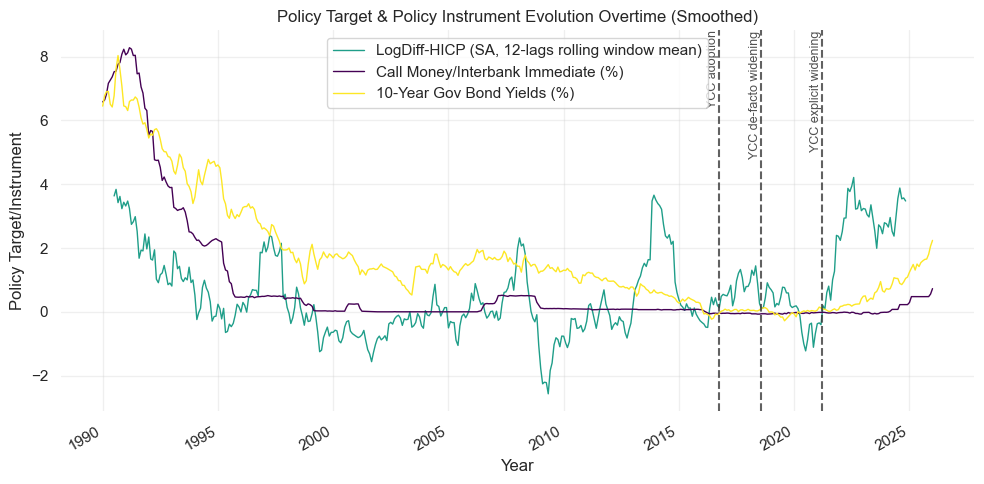

In [721]:
# Over time plotting (Raw Data): Policy Target (LogDiff-HICP (SA)) and Policy Instrument (Call Money/Interbank Immediate (%), 10-Year Gov Bond Yields (%)) 

fig, ax = plt.subplots(figsize=(10, 5))

# Index settings for the 2 datasets (jp_aggregated_df and jp_core_trans_df)
# (!!!) We also restrict the sample to observations later than 01/01/1990
jp_core_trans_df = jp_core_trans_df.reset_index()
jp_core_trans_df["Time"] = pd.to_datetime(jp_core_trans_df["Time"]) 
jp_core_trans_df = jp_core_trans_df.set_index("Time")
df1 = jp_core_trans_df.copy()
df1 = df1[df1.index >= "1990-01-01"]

jp_aggregated_df = jp_aggregated_df.reset_index()
jp_aggregated_df["Time"] = pd.to_datetime(jp_aggregated_df["Time"]) 
jp_aggregated_df = jp_aggregated_df.set_index("Time")
df2 = jp_aggregated_df.copy()
df2 = df2[df2.index >= "1990-01-01"]

# Smoothing Inflation (Rolling-Window Average)
df1["LogDiff-HICP (SA)-smooth"] = df1["LogDiff-HICP (SA)"].rolling(window=12, center=True).mean()

# Plot set-up 
# (!!!) Separate plotting for raw and transformed variables
ax.plot(
    df1.index,
    df1["LogDiff-HICP (SA)-smooth"],
    label="LogDiff-HICP (SA, 12-lags rolling window mean)",
    linewidth=1,
    color = "#1F9E89"
    )

ax.plot(
    df2.index,
    df2["Call Money/Interbank Immediate (%)"],
    label= "Call Money/Interbank Immediate (%)",
    linewidth=1,
    color = "#440154"
    )
ax.plot(
    df2.index,
    df2["10-Year Gov Bond Yields (%)"],
    label="10-Year Gov Bond Yields (%)",
    linewidth=1,
    color = "#FDE725"
    )

# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    ycc_date,
    ax.get_ylim()[1],
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1],
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
    zorder=10
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1],
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"Policy Target & Policy Instrument Evolution Overtime (Smoothed)")
ax.set_xlabel("Year")
ax.set_ylabel(f"Policy Target/Instrument")
ax.grid(True, alpha=0.3)
ax.legend()

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

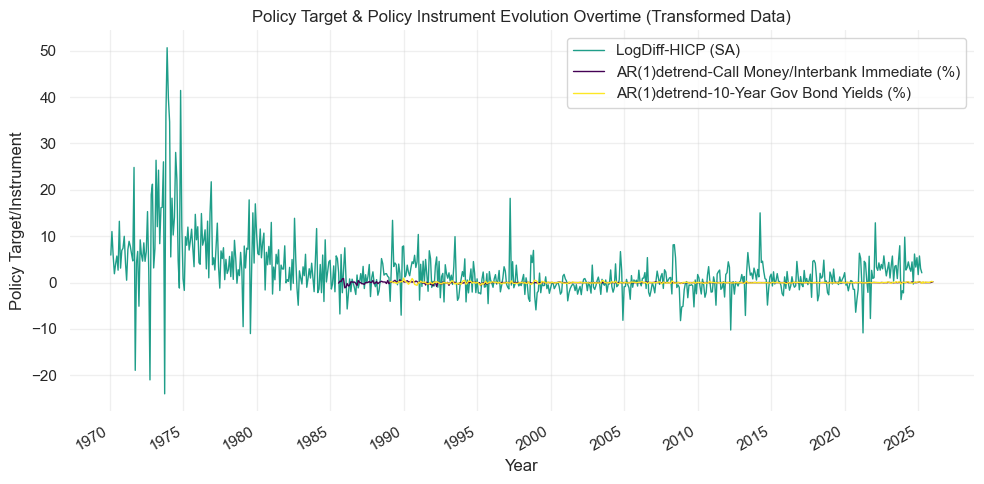

In [722]:
# Over time plotting (Transformed Data): Policy Target (LogDiff-HICP (SA)) and Policy Instrument (AR(1)detrend-Call Money/Interbank Immediate (%), AR(1)detrend-10-Year Gov Bond Yields (%)) 

df = jp_core_trans_df.copy()
df = df.reset_index()
df["Time"] = pd.to_datetime(df["Time"]) 
df = df.set_index("Time")
core_var = ["LogDiff-HICP (SA)", "AR(1)detrend-Call Money/Interbank Immediate (%)", "AR(1)detrend-10-Year Gov Bond Yields (%)"]

fig, ax = plt.subplots(figsize=(10, 5))

# Loop on variable (without country and time)
for var in core_var: 
# Plot set-up
# (!!!) Check countries naming
    ax.plot(
        df.index,
        df[var],
        label=var,
        linewidth=1,
        color = core_trans_var_colors.get(var)
    )
# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"Policy Target & Policy Instrument Evolution Overtime (Transformed Data)")
ax.set_xlabel("Year")
ax.set_ylabel(f"Policy Target/Instrument")
ax.grid(True, alpha=0.3)
ax.legend()

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### **3) AR(1) PROCESS ESTIMATION**

In [723]:
# AR(1) Process Estimation - Inflation (LogDiff-HICP (SA))

# Inflation (pi)
pi = jp_core_trans_df["LogDiff-HICP (SA)"].dropna()
# AR(1) on inflation
# (!!!) We start from period 2 cuz otherwise we wont have observations for pi_t-1
# pi_t
pi_t  = pi.values[1:]
# pi_t-1
pi_tm1  = sm.add_constant(pi.values[:-1])
# Estimates
ar1_pi = sm.OLS(pi_t, pi_tm1).fit()
print(ar1_pi.summary())

# Residuals of inflation AR(1) (u_pi)
u_pi = ar1_pi.resid
# u_pi_t
u_pi_t = u_pi[1:]
# u_pi_t-1
u_pi_tm1 = sm.add_constant(u_pi[:-1])
# Residuals Estimates
ar1mar1_pi = sm.OLS(u_pi_t, u_pi_tm1).fit()
print(ar1mar1_pi.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     85.69
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.90e-19
Time:                        07:49:59   Log-Likelihood:                -2104.0
No. Observations:                 662   AIC:                             4212.
Df Residuals:                     660   BIC:                             4221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5614      0.242      6.447      0.0

In [724]:
# AR(1) Process Estimation - Policy Instrument (Call Money/Interbank Immediate (%), not transformed)

# Policy Instrument (i)
i = jp_aggregated_df["Call Money/Interbank Immediate (%)"].dropna()
# AR(1) on policy instrument
# (!!!) We start from period 2 cuz otherwise we wont have observations for i_t-1
# i_t
i_t = i.values[1:]
# i_t-1
i_tm1 = sm.add_constant(i.values[:-1])
# Estimates
ar1_i = sm.OLS(i_t, i_tm1).fit()
print(ar1_i.summary())

# Residuals of policy instrument AR(1) (u_i)
u_i = ar1_i.resid
# u_i_t
u_i_t = u_i[1:]
# u_i_t-1
u_i_tm1 = sm.add_constant(u_i[:-1])
# Residuals Estimates
ar1mar1_i = sm.OLS(u_i_t, u_i_tm1).fit()
print(ar1mar1_i.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 9.252e+04
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        07:49:59   Log-Likelihood:                 211.00
No. Observations:                 486   AIC:                            -418.0
Df Residuals:                     484   BIC:                            -409.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.008     -0.161      0.8

In [725]:
# AR(1) Process Estimation - Output Gap (HPfilter-Real GDP (billions chained 2015 JPY))
# (!!!) The HP filter output gap is actually the more standard choice in DSGE and monetary policy models since it directly maps to the output gap term in the Taylor rule. 

# Output Gap (y)
y = jp_trans_df["HPfilter-Real GDP (billions chained 2015 JPY)"].dropna()
# AR(1) on output gap
# (!!!) We start from period 2 cuz otherwise we wont have observations for y_t-1
# y_t
y_t = y.values[1:]
# y_t-1
y_tm1 = sm.add_constant(y.values[:-1])
# Estimates
ar1_y = sm.OLS(y_t, y_tm1).fit()
print(ar1_y.summary())

# Residuals of output gap AR(1) (u_y)
u_y = ar1_y.resid
# u_y_t
u_y_t = u_y[1:]
# u_y_t-1
u_y_tm1 = sm.add_constant(u_y[:-1])
# Residuals Estimates
ar1mar1_y = sm.OLS(u_y_t, u_y_tm1).fit()
print(ar1mar1_y.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     432.5
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           9.87e-65
Time:                        07:50:00   Log-Likelihood:                 1390.4
No. Observations:                 383   AIC:                            -2777.
Df Residuals:                     381   BIC:                            -2769.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.739e-05      0.000     -0.083      0.9

### **4) RAW DATA AR(1) UNIT ROOT TESTING**

In [726]:
# Autocorrelation coefficients AR(1)
# Drop non-numeric columns and rows with missing values
df = jp_core_hybrid_df.copy()
jp_core_hybrid_numeric = df.drop(columns=["Country", "Time"]).dropna()

# AR(1) autocorrelation for each variable
ar1_results = {}
for col in jp_core_hybrid_numeric.columns:
    series = jp_core_hybrid_numeric[col]

# (!!!) lag-1 autocorrelation
    ar1 = series.autocorr(lag=1)
    ar1_results[col] = ar1

# Better to create a dataframe to display the results
jp_ar1_df = pd.DataFrame.from_dict(ar1_results, orient="index", columns=["AR(1)"])
jp_ar1_df

,AR(1)
LogDiff-HICP (SA),0.164478
Call Money/Interbank Immediate (%),0.998457
10-Year Gov Bond Yields (%),0.996330


In [727]:
# Unit-root Testing - Adfuller Test 
# Drop non-numeric columns and handle missing data
df = jp_core_hybrid_df.copy()
jp_core_hybrid_numeric = df.drop(columns=["Country", "Time"]).dropna()

# (!!!) We need to initialize the results as empty list before execuding the test
results = []

for col in jp_core_hybrid_numeric.columns:
    series = jp_core_hybrid_numeric[col]

# As before, we extract the AR(1) coefficients
    ar1 = series.autocorr(lag=1)

# Augmented Dickey-Fuller (ADF) unit root test 
    adf_result = adfuller(series, autolag="AIC")
    adf_stat = adf_result[0]
    p_value = adf_result[1]
    crit_values = adf_result[4]

    results.append({
        "Variable": col,
        "AR(1)": ar1,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Stationary - Absence of unit-root (HP1)": "Yes" if p_value < 0.05 else "No"
    })

jp_adf_df = pd.DataFrame(results)
jp_adf_df

,Variable,AR(1),ADF Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-HICP (SA),0.164478,-4.495569,0.000200,Yes
1,Call Money/Interbank Immediate (%),0.998457,-4.747988,0.000068,Yes
2,10-Year Gov Bond Yields (%),0.996330,-1.783089,0.388889,No


In [728]:
# Unit-root Testing - Phillips-Perron Test 
# (!!!) We need to initialize the results as empty list before execuding the test
pp_results = []

for col in jp_core_hybrid_numeric.columns:
    series = jp_core_hybrid_numeric[col].dropna()
    
# Phillips–Perron test 
# (!!!) From arch instead of stats.models is much smoother
    test = PhillipsPerron(series)
    pp_results.append({
        "Variable": col,
        "PP Statistic": test.stat,
        "p-value": test.pvalue,
        "Stationary - Absence of unit-root (HP1)": "Yes" if test.pvalue < 0.05 else "No"
    })

jp_pp_df = pd.DataFrame(pp_results)
jp_pp_df

,Variable,PP Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-HICP (SA),-20.024675,0.000000,Yes
1,Call Money/Interbank Immediate (%),-1.782157,0.389356,No
2,10-Year Gov Bond Yields (%),-1.623684,0.470798,No


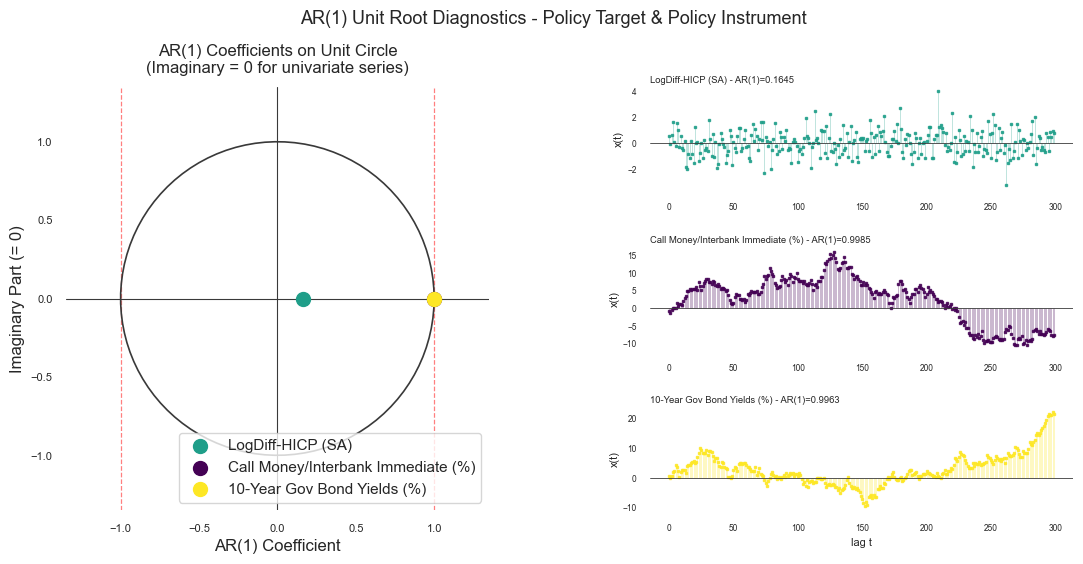

In [729]:
# AR(1) Unit-Root Circle Plotting 

# General settings & Parameters
# We extract values and parameters from the ADF unit root tests
core_variables = jp_adf_df["Variable"].tolist()
ar1_values = jp_adf_df["AR(1)"].values         
stationary  = jp_adf_df["Stationary - Absence of unit-root (HP1)"].tolist()
# Angle of the circle
theta = np.linspace(0, 2 * np.pi, 100)
# Color Palette 
palette = ["#1F9E89", "#440154", "#FDE725"]
colors  = [palette[i % len(palette)] for i in range(len(core_variables))]
# Figure settings
fig = plt.figure(figsize=(13, 5.5), facecolor="#ffffff")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)





# Unit Root Circle
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#ffffff")

# Plot components:
# 1) Unit circle
ax1.plot(np.cos(theta), np.sin(theta), color="#393939", lw=1.2, zorder=1)
# 2) Vertical and horizontal axes (0,0)
ax1.axhline(0, color="#393939", lw=0.8, zorder=0)
ax1.axvline(0, color="#393939", lw=0.8, zorder=0)
# 3) +1, -1 Vertical Stationarity limits (-1, +1)
ax1.axvline(1.0,  color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)
ax1.axvline(-1.0, color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)

# Variables lambda on the circle 
# AR(1) coefficients live on the real axis (imaginary = 0)
for i, (ar1, var, stat, col) in enumerate(zip(ar1_values, core_variables, stationary, colors)):
# (!!!) To plot the lambda point we can use the scatter function
    ax1.scatter(ar1, 0, color=col, s=100, zorder=4, linewidths=1.0, label=var)

# Subplot settings
# (!!!) Set .set_aspect to "equal" and not "auto" or it deforms the unit root circle into an ellipse
ax1.set_xlim(-1.35, 1.35)
ax1.set_ylim(-1.35, 1.35)
ax1.set_aspect("equal")
ax1.set_title("AR(1) Coefficients on Unit Circle\n(Imaginary = 0 for univariate series)", pad=10)
ax1.set_xlabel("AR(1) Coefficient")
ax1.set_ylabel("Imaginary Part (= 0)")
ax1.tick_params(labelsize=8)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.legend(loc="lower right")







# Simulated AR(1) processes 
# Grid settings
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38) 
gs_right = gridspec.GridSpecFromSubplotSpec(
    len(core_variables), 1,
    subplot_spec=gs[1],
    hspace=0.55
)

# Simulation Parameters
# Random seed
np.random.seed(42)
# Number of steps to simulate
N = 300

# Simulation Plotting
for i, (var, ar1, col, stat) in enumerate(zip(core_variables, ar1_values, colors, stationary)):
    ax = fig.add_subplot(gs_right[i])
    ax.set_facecolor("#ffffff")
# Simulation of the AR(1) process: x_t = ar1 * x_{t-1} + u_t
    eps = np.random.normal(0, 1, N)
    y = np.zeros(N)
    y[0] = eps[0]
    for t in range(1, N):
        y[t] = ar1 * y[t - 1] + eps[t]
# Stem-style plot (squared dots with hortogonal lines to the 0 axis)
    markerline, stemlines, baseline = ax.stem(
        np.arange(N), y,
        linefmt=col,
        markerfmt=f"s",           
        basefmt=" "               
    )
    plt.setp(stemlines, lw=0.4, alpha=0.5, color=col)
    plt.setp(markerline, markersize=2.0, color=col, alpha=0.85)
# Horizontal zero line
    ax.axhline(0, color="#393939", lw=0.6)
# Cosmetics
    ax.set_title(
        f"{var} - AR(1)={ar1:.4f}",
        fontsize=6.8, loc="left", pad=3
    )
# ylabel: x(t)
    ax.set_ylabel("x(t)", fontsize=8, labelpad=2)
    ax.tick_params(labelsize=6)
    for spine in ax.spines.values():
        spine.set_visible(False)
# xlabel (we only plot the x label on the last bottom subplot)
    if i == len(core_variables) - 1:
        ax.set_xlabel("lag t", fontsize=8)






plt.suptitle("AR(1) Unit Root Diagnostics - Policy Target & Policy Instrument", fontsize=13, y=1.02)
plt.show()

In [730]:
# Autocorrelation coefficients AR(1)
# Drop non-numeric columns and rows with missing values
df = jp_trans_df.copy()
jp_transformed_numeric = df.drop(columns=["Country", "Time"]).dropna()

# AR(1) autocorrelation for each variable
ar1_results = {}
for col in jp_transformed_numeric.columns:
    series = jp_transformed_numeric[col]

# (!!!) lag-1 autocorrelation
    ar1 = series.autocorr(lag=1)
    ar1_results[col] = ar1

# Better to create a dataframe to display the results
jp_ar1_df = pd.DataFrame.from_dict(ar1_results, orient="index", columns=["AR(1)"])
jp_ar1_df

,AR(1)
LogDiff-Monetary Aggregates - M1 (JPY),0.345322
LogDiff-Monetary Aggregates - M2 (JPY),0.166549
LogDiff-Monetary Aggregates - M3 (JPY),0.266801
LogDiff-Total Treasury Reserves (- Gold),-0.011823
LogDiff-USD-JPY reer CPI-based (Index 2015=100),0.360096
LogDiff-JPY-USD Spot Exchange Rate,0.317363
LogDiff-HICP (SA),0.302991
LogDiff-1615.T-Price,0.083562
LogDiff-BoJ’s Total Assets (100 Million Yen),-0.234426
LogDiff-Call Money/Interbank Immediate (%),0.163523


### **5) AR(2) PROCESS ESTIMATION**

In [731]:
# AR(2) Process Estimation - Inflation (LogDiff-HICP (SA))

# Inflation (pi)
pi = jp_core_trans_df["LogDiff-HICP (SA)"].dropna()
# AR(1) on inflation
# (!!!) We start from period 3 cuz otherwise we wont have observations for pi_t, pi_t-2
# (!!!) Instead of pi_t+1 like the problem set says, we use pi_t, i like it better for comparability 
# pi_t, pi_t-1, pi_t-2
pi_t   = pi.values[2:]          
pi_tm1 = pi.values[1:-1]       
pi_tm2 = pi.values[:-2] 
# Constant
X_ar2 = sm.add_constant(np.column_stack([pi_tm1, pi_tm2]))
# Estimates
ar2_pi = sm.OLS(pi_t, X_ar2).fit()
print(ar2_pi.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     55.95
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           3.61e-23
Time:                        07:50:03   Log-Likelihood:                -2088.8
No. Observations:                 661   AIC:                             4184.
Df Residuals:                     658   BIC:                             4197.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2603      0.246      5.134      0.0

In [732]:
# AR(2) Process Estimation - Policy Instrument (Call Money/Interbank Immediate (%), not transformed)

# Policy Instrument (i)
i = jp_aggregated_df["Call Money/Interbank Immediate (%)"].dropna()
# AR(1) on policy instrument
# (!!!) We start from period 3 cuz otherwise we wont have observations for i_t-1 and i_t-1
# (!!!) Instead of i_t+1 like the problem set says, we use i_t, i like it better for comparability 
# i_t, i_t-1, i_t-2
i_t = i.values[2:]          
i_tm1 = i.values[1:-1]       
i_tm2 = i.values[:-2] 
# Constant
X_ar2 = sm.add_constant(np.column_stack([i_tm1, i_tm2]))
# Estimates
ar2_i = sm.OLS(i_t, X_ar2).fit()
print(ar2_i.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 4.845e+04
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        07:50:03   Log-Likelihood:                 224.90
No. Observations:                 485   AIC:                            -443.8
Df Residuals:                     482   BIC:                            -431.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.008      0.072      0.9

In [733]:
# AR(2) Process Estimation - Output Gap (HPfilter-Real GDP (billions chained 2015 JPY))
# (!!!) The HP filter output gap is actually the more standard choice in DSGE and monetary policy models since it directly maps to the output gap term in the Taylor rule. 

# Output Gap (y)
y = jp_trans_df["HPfilter-Real GDP (billions chained 2015 JPY)"].dropna()
# AR(1) on output gap
# (!!!) We start from period 2 cuz otherwise we wont have observations for y_t-1, y-t-2
# (!!!) Instead of y_t+1 like the problem set says, we use y_t, i like it better for comparability 
# y_t, y_t-1, y_t-2
y_t = y.values[2:]          
y_tm1 = y.values[1:-1]       
y_tm2 = y.values[:-2] 
# Constant
X_ar2 = sm.add_constant(np.column_stack([y_tm1, y_tm2]))
# Estimates
ar2_y = sm.OLS(y_t, X_ar2).fit()
print(ar2_y.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.531
Method:                 Least Squares   F-statistic:                     216.5
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.94e-63
Time:                        07:50:03   Log-Likelihood:                 1387.3
No. Observations:                 382   AIC:                            -2769.
Df Residuals:                     379   BIC:                            -2757.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.892e-05      0.000     -0.088      0.9

### **6) AR(2) UNIT ROOT TESTING**

In [734]:
# AR(2) Unit Root Testing - Inflation

# Parameters Definitions
# (!!!) We have the 3 parameters of delta, a,b,c bringing delta to zero
# (!!!) a=const, b=phi_t-1 (pi_t-1) and c=phi_t-2 (pi_t-2)
# Extraction from the previous estimates:
# Constant (a):
const = ar2_pi.params[0]
# phi_t-1 (b):
pi_phi_tm1  = ar2_pi.params[1]
# phi_t-2 (c):
pi_phi_tm2 = ar2_pi.params[2]  

# Characteristic polynomial: 
# X² - (λ_π + ρ_π)X - λ_π ρ_π = 0
# (!!!) Command to get the roots from the coefficients: np.roots(coeffs)
# coeff = [a, b, c]
coeffs = [1, -(pi_phi_tm1 + pi_phi_tm2), -(pi_phi_tm1 * pi_phi_tm2)]
pi_ar2_roots  = np.roots(coeffs)

# Results
# (!!!) Complex coniugate happens when delta<0, so only defined in i
rows = []
for i, r in enumerate(pi_ar2_roots):
    rows.append({
        "Lagged Variable" : f"pi_{i+1}",
        "Root" : f"{r}",
        "Modulus |X|": round(abs(r), 6),
        "Inside Unit Disk (|X|<1)" : "Yes" if abs(r) < 1 else "No",
        "Real Root or Complex Conjugate (Δ<0)" : "Real Root" if np.isreal(r) else "Complex conjugate"
    })

pi_AR2_roots = pd.DataFrame(rows).set_index("Lagged Variable")
pi_AR2_roots

,Root,Modulus |X|,Inside Unit Disk (|X|<1),Real Root or Complex Conjugate (Δ<0)
Lagged Variable,,,,
pi_1,0.5535652303577507,0.553565,Yes,Real Root
pi_2,-0.09249556789624543,0.092496,Yes,Real Root


In [735]:
# AR(2) Unit Root Testing - Policy Instrument

# Parameters Definitions
# (!!!) We have the 3 parameters of delta, a,b,c bringing delta to zero
# (!!!) a=const, b=phi_t-1 (i_t-1) and c=phi_t-2 (i_t-2)
# Extraction from the previous estimates:
# Constant (a):
const = ar2_i.params[0]
# phi_t-1 (b):
i_phi_tm1  = ar2_i.params[1]
# phi_t-2 (c):
i_phi_tm2 = ar2_i.params[2]  

# Characteristic polynomial: 
# X² - (λ_i + ρ_i)X - λ_i ρ_i = 0
# (!!!) Command to get the roots from the coefficients: np.roots(coeffs)
# coeff = [a, b, c]
coeffs = [1, -(i_phi_tm1 + i_phi_tm2), -(i_phi_tm1 * i_phi_tm2)]
i_ar2_roots  = np.roots(coeffs)

# Results
rows = []
for i, r in enumerate(i_ar2_roots):
    rows.append({
        "Lagged Variable" : f"i_{i+1}",
        "Root" : f"{r}",
        "Modulus |X|": round(abs(r), 6),
        "Inside Unit Disk (|X|<1)" : "Yes" if abs(r) < 1 else "No",
        "Real Root or Complex Conjugate (Δ<0)" : "Real Root" if np.isreal(r) else "Complex conjugate"
    })

i_AR2_roots = pd.DataFrame(rows).set_index("Lagged Variable")
i_AR2_roots

,Root,Modulus |X|,Inside Unit Disk (|X|<1),Real Root or Complex Conjugate (Δ<0)
Lagged Variable,,,,
i_1,(0.4963428697748463+0.22312277411540954j),0.544187,Yes,Complex conjugate
i_2,(0.4963428697748463-0.22312277411540954j),0.544187,Yes,Complex conjugate


<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
<>:116: SyntaxWarning: invalid escape sequence '\p'
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\856913231.py:116: SyntaxWarning: invalid escape sequence '\p'
  f"{var} — $\phi_1$={phi1:.4f}, $\phi_2$={phi2:.4f}, $|X|$={mod:.4f}",
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\856913231.py:116: SyntaxWarning: invalid escape sequence '\p'
  f"{var} — $\phi_1$={phi1:.4f}, $\phi_2$={phi2:.4f}, $|X|$={mod:.4f}",


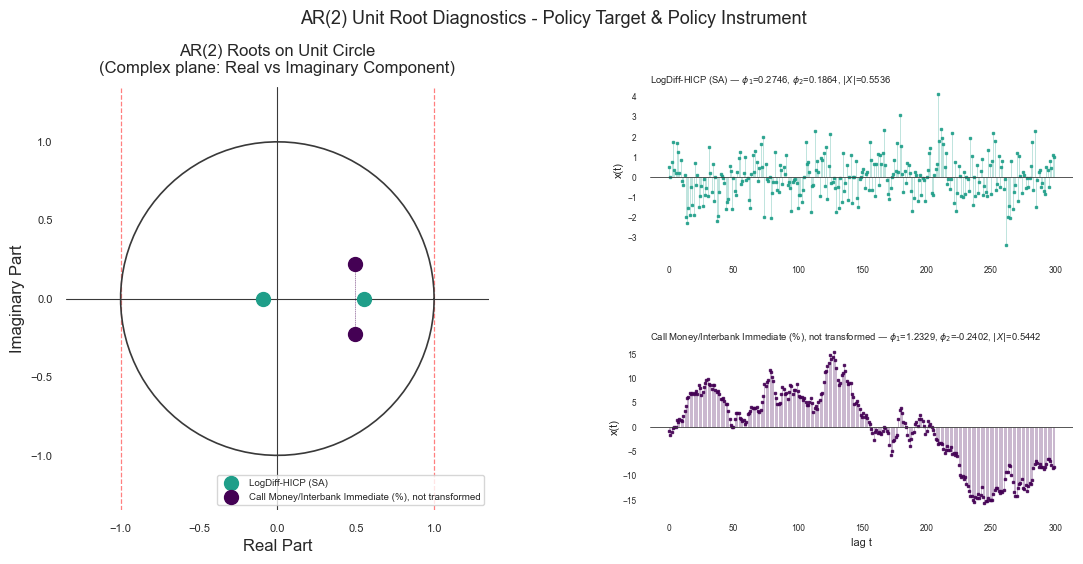

In [736]:
# AR(2) Unit-Root Circle Plotting
# (!!!) Pretty much the same thing as for AR(1) but i need to specify the variables differently because now they are saved in two different dfs while before they were incorporated in the same adf/pp df

# General settings & Parameters
# AR(2) coefficients from previous OLS estimates
# Variable labels, root sets and AR(2) coefficient pairs for simulation
core_variables = ["LogDiff-HICP (SA)", "Call Money/Interbank Immediate (%), not transformed"]
all_roots      = [pi_ar2_roots, i_ar2_roots]
ar2_params     = [(pi_phi_tm1, pi_phi_tm2), (i_phi_tm1, i_phi_tm2)]
# Angle of the circle
theta = np.linspace(0, 2 * np.pi, 100)
# Color Palette
palette = ["#1F9E89", "#440154", "#FDE725"]
colors  = [palette[i % len(palette)] for i in range(len(core_variables))]
# Figure settings
fig = plt.figure(figsize=(13, 5.5), facecolor="#ffffff")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)




# Unit Root Circle
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#ffffff")

# Plot components:
# 1) Unit circle
ax1.plot(np.cos(theta), np.sin(theta), color="#393939", lw=1.2, zorder=1)
# 2) Vertical and horizontal axes (0,0)
ax1.axhline(0, color="#393939", lw=0.8, zorder=0)
ax1.axvline(0, color="#393939", lw=0.8, zorder=0)
# 3) +1, -1 Vertical Stationarity limits (-1, +1)
ax1.axvline( 1.0, color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)
ax1.axvline(-1.0, color="#ff0000", lw=0.9, linestyle="--", alpha=0.5, zorder=0)

# Variables roots on the circle
# AR(2) roots can be complex: plot real part on x-axis, imaginary part on y-axis
for i, (roots, var, col) in enumerate(zip(all_roots, core_variables, colors)):
    for j, r in enumerate(roots):
# (!!!) To plot the root point we use the scatter function 
# (!!!) This is the main difference from AR(1), we decompose the root in its real and imaginary part, that will be plotted on the y axis 
        ax1.scatter(
            r.real, r.imag,
            color=col, s=100, zorder=4, linewidths=1.0,
# (!!!) "_nolegend_" is fire, it removes the legend without using an if clause 
            label=f"{var}" if j == 0 else "_nolegend_"
        )
# Exception for conjugates pairs
# (!!!) We connect the two opposite solutions with a dot line
        if not np.isreal(r):
            ax1.plot([r.real, r.real], [r.imag, -r.imag],
                     color=col, lw=0.6, linestyle=":", alpha=0.5, zorder=2)

# Subplot settings
# (!!!) Set .set_aspect to "equal" and not "auto" or it deforms the unit root circle into an ellipse
ax1.set_xlim(-1.35, 1.35)
ax1.set_ylim(-1.35, 1.35)
ax1.set_aspect("equal")
ax1.set_title("AR(2) Roots on Unit Circle\n(Complex plane: Real vs Imaginary Component)", pad=10)
ax1.set_xlabel("Real Part")
ax1.set_ylabel("Imaginary Part")
ax1.tick_params(labelsize=8)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.legend(loc="lower right", fontsize=7)








# Simulated AR(2) processes
# (!!!) Same as before but we add the second coefficient for x_t-2

# Grid settings
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.38)
gs_right = gridspec.GridSpecFromSubplotSpec(
    len(core_variables), 1,
    subplot_spec=gs[1],
    hspace=0.55
)
# Simulation Parameters
# Random seed
np.random.seed(42)
# Number of steps to simulate
N = 300

# Simulation Plotting
for i, (var, (phi1, phi2), col, roots) in enumerate(zip(core_variables, ar2_params, colors, all_roots)):
    ax = fig.add_subplot(gs_right[i])
    ax.set_facecolor("#ffffff")
# Simulation of the AR(2) process: x_t = phi1 * x_{t-1} + phi2 * x_{t-2} + u_t
    eps = np.random.normal(0, 1, N)
    y   = np.zeros(N)
    y[0] = eps[0]
    y[1] = phi1 * y[0] + eps[1]
    for t in range(2, N):
        y[t] = phi1 * y[t - 1] + phi2 * y[t - 2] + eps[t]
# Stem-style plot (squared dots with orthogonal lines to the 0 axis)
    markerline, stemlines, baseline = ax.stem(
        np.arange(N), y,
        linefmt=col,
        markerfmt="s",
        basefmt=" "
    )
    plt.setp(stemlines,  lw=0.4, alpha=0.5, color=col)
    plt.setp(markerline, markersize=2.0, color=col, alpha=0.85)
# Horizontal zero line
    ax.axhline(0, color="#393939", lw=0.6)
# Cosmetics
# Modulus of the first root (both share same modulus for conjugate pairs)
    mod = abs(roots[0])
    ax.set_title(
        f"{var} — $\phi_1$={phi1:.4f}, $\phi_2$={phi2:.4f}, $|X|$={mod:.4f}",
        fontsize=6.8, loc="left", pad=3
    )
# ylabel: x(t)
    ax.set_ylabel("x(t)", fontsize=8, labelpad=2)
    ax.tick_params(labelsize=6)
    for spine in ax.spines.values():
        spine.set_visible(False)
# xlabel (we only plot the x label on the last bottom subplot)
    if i == len(core_variables) - 1:
        ax.set_xlabel("lag t", fontsize=8)





plt.suptitle("AR(2) Unit Root Diagnostics - Policy Target & Policy Instrument", fontsize=13, y=1.02)
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:90: SyntaxWarning: invalid escape sequence '\p'
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\1579274721.py:38: SyntaxWarning: invalid escape sequence '\p'
  ax.text( 1.2,  0.05, f"$\phi_1$*$\phi_2$ = ($\phi_1$ + $\phi_2$) - 1", fontsize=8, color="#6DCD59")
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\1579274721.py:39: SyntaxWarning: invalid escape sequence '\p'
  ax.text(-2.1,  0.05, f"$\phi_1$*$\phi_2$ = -($\phi_1$ + $\phi_2$) - 1", fontsize=8, color="#6DCD59")
C:\Users\eland\AppData\Local\Temp\ipykernel_16808\1579274721.

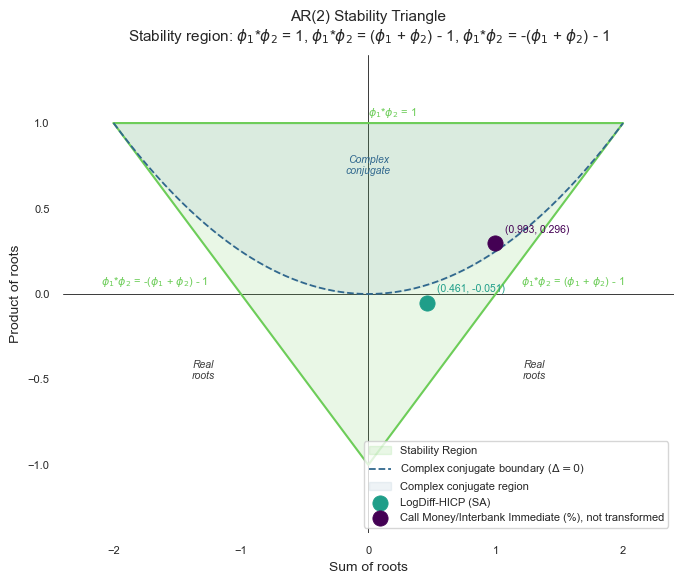

In [737]:
# AR(2) Unit Root Stability Triangle Plotting 
# (!!!) Stability conditions: 
# 1) phi_t-1*phi_t-2 < 1
# 2) phi_t-1*phi_t-2 > (phi_t-1 + phi_t-2)  - 1       
# 3) phi_t-1*phi_t-2 > -(phi_t-1 + phi_t-2) - 1     
# (!!!) So the vertices are in: (-2, 1), (2, 1), (0, -1)

# Variable Definition (phis for t-1 and t-2)
# Inflation
# Sum of phis 
sum_pi = pi_phi_tm1 + pi_phi_tm2
# Product of phis     
# (!!!) Remember the minus!!!   
product_pi = -(pi_phi_tm1*pi_phi_tm2)          
# Policy Instrument
# Same thing
sum_i  = i_phi_tm1 + i_phi_tm2         
product_i = -(i_phi_tm1*i_phi_tm2)           

# Stability Triangle Plotting
# General Settings
fig, ax = plt.subplots(figsize=(7, 6), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

# Vertoces and stability region
# (!!!) the vertices are in: (-2, 1), (2, 1), (0, -1)
# Limit Sum 
# (!!!) Obviously each phi cannot exceed 1 in module or it would lead to increasing x, so the max must be either +2 or -2
triangle_sum = np.array([-2,  2,  0, -2])
# Limit Product
# (!!!) As we have just set the limit of the sum of coefficients to |2|, the maximum product we can get with two terms is |1| when both coefficients are on the hedge
triangle_product = np.array([ 1,  1, -1,  1])
ax.fill(triangle_sum, triangle_product, color="#6DCD59", alpha=0.15, label="Stability Region")
ax.plot(triangle_sum, triangle_product, color="#6DCD59", lw=1.5)

# Boundary labels
# (!!!) Remember to not rotate the ticks for left and right boundaries (too complicated) and use only the horizzontal axis to locate the labels
ax.text( 1.2,  0.05, f"$\phi_1$*$\phi_2$ = ($\phi_1$ + $\phi_2$) - 1", fontsize=8, color="#6DCD59")
ax.text(-2.1,  0.05, f"$\phi_1$*$\phi_2$ = -($\phi_1$ + $\phi_2$) - 1", fontsize=8, color="#6DCD59")
ax.text(0,  1.04, f"$\phi_1$*$\phi_2$ = 1", fontsize=8, color="#6DCD59")

# Complex conjugate boundary curve
# (!!!) Discriminant Δ = S² - 4P = 0 → P = S²/4
# (!!!) Above the parabola (P > S²/4): complex conjugate roots, below the parabola (P < S²/4): real roots
# (!!!) Same limits for the sum operator we have just seen (-2, +2)
sum_curve = np.linspace(-2, 2, 300)
product_curve = (sum_curve**2) / 4
mask = product_curve <= 1
ax.plot(sum_curve, product_curve,
        color="#31688E", lw=1.3, linestyle="--",
        label=f"Complex conjugate boundary ($\Delta=0$)")
# (!!!) fill_between is cleaner than fill() here: fills between parabola and P=1 top boundary
ax.fill_between(sum_curve, product_curve, 1,
                color="#31688E", alpha=0.08,
                label="Complex conjugate region")

# Region labels for real roots and complex conjugates
ax.text(0.0,  0.7, "Complex\nconjugate", fontsize=7.5,
        color="#31688E", ha="center", style="italic")
ax.text(1.3, -0.5, "Real\nroots", fontsize=7.5,
        color="#393939", ha="center", style="italic")
ax.text(-1.3, -0.5, "Real\nroots", fontsize=7.5,
        color="#393939", ha="center", style="italic")

# Reference axes
ax.axhline(0, color="#393939", lw=0.7, zorder=0)
ax.axvline(0, color="#393939", lw=0.7, zorder=0)

# Roots points
# (!!!) Exactely as for the circle
core_variables = ["LogDiff-HICP (SA)", "Call Money/Interbank Immediate (%), not transformed"]
sum_operator = [sum_pi, sum_i]
product_operator =[product_pi, product_i]
palette = ["#1F9E89", "#440154"]
for S, P, var, col in zip(sum_operator, product_operator, core_variables, palette):
    ax.scatter(S, P, color=col, s=120, zorder=5, edgecolors= col, lw=0.6, label=var)
# Point Label
    ax.annotate(
        f"({S:.3f}, {P:.3f})",
        xy=(S, P), xytext=(S + 0.08, P + 0.06),
        fontsize=7.5, color=col
    )

# Cosmetics
ax.set_xlim(-2.4, 2.4)
ax.set_ylim(-1.4, 1.4)
ax.set_xlabel(f"Sum of roots",     fontsize=10)
ax.set_ylabel(f"Product of roots", fontsize=10)
ax.set_title("AR(2) Stability Triangle\n"
             f"Stability region: $\phi_1$*$\phi_2$ = 1, $\phi_1$*$\phi_2$ = ($\phi_1$ + $\phi_2$) - 1, $\phi_1$*$\phi_2$ = -($\phi_1$ + $\phi_2$) - 1",
             fontsize=11, pad=10)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8, loc="lower right")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### **7) AR(p) LIMIT TO STABILITY**

In [738]:
# AR(p) Lag Order Selection - LogDiff-HICP (SA)
# (!!!) Nothing new, same approach as before, jus that instead of having a fixed autocorrelation coefficient, like 1 or 2, we investigate at which lag the deviation becomes unstable (p+1)

# Policy Instrument (pi)
pi = jp_core_trans_df["LogDiff-HICP (SA)"].dropna()
# Lag (available)
t = len(pi)
# Confidence Level (95%) 
confidence_level = 1.96 / np.sqrt(t)
# Partial Autocorrelation Function (PACF)
# (!!!) We test for 20 lags, the correlation coefficient
pacf_vals = pacf(pi, nlags=10)

# AR order 
# (!!!) Last lag where |PACF| > confidence band
rows = []
# (!!!) i stands for index here, and we exclude lag 0
for idx, pac in enumerate(pacf_vals[1:]):
    rows.append({
        "Lag (p)" : f"{idx+1}",
        "Partial Autocorrelation Coefficient" : f"{round(pac,5)}",
# (!!!) Do not forget the abs() function to consider also negative values
        "Significant (95% confidence level)" : "Yes" if abs(pac) > confidence_level else "No"
    })

pi_ARp = pd.DataFrame(rows).set_index("Lag (p)")
pi_ARp

,Partial Autocorrelation Coefficient,Significant (95% confidence level)
Lag (p),,
1,0.33941,Yes
2,0.18666,Yes
3,0.23619,Yes
4,0.20713,Yes
5,0.18694,Yes
6,0.17122,Yes
7,0.11749,Yes
8,0.13471,Yes
9,0.1376,Yes


In [739]:
# AR(p) Lag Order Selection - Policy Instrument (Call Money/Interbank Immediate (%), not transformed)
# (!!!) Nothing new, same approach as before, jus that instead of having a fixed autocorrelation coefficient, like 1 or 2, we investigate at which lag the deviation becomes unstable (p+1)

# Policy Instrument (i)
i = jp_aggregated_df["Call Money/Interbank Immediate (%)"].dropna()
# Lag (available)
t = len(i)
# Confidence Level (95%) 
confidence_level = 1.96 / np.sqrt(t)
# Partial Autocorrelation Function (PACF)
# (!!!) We test for 20 lags, the correlation coefficient
pacf_vals = pacf(i, nlags=10)

# AR order 
# (!!!) Last lag where |PACF| > confidence band
rows = []
# (!!!) i stands for index here, and we exclude lag 0
for idx, pac in enumerate(pacf_vals[1:]):
    rows.append({
        "Lag (p)" : f"{idx+1}",
        "Partial Autocorrelation Coefficient" : f"{round(pac,5)}",
# (!!!) Do not forget the abs() function to consider also negative values
        "Significant (95% confidence level)" : "Yes" if abs(pac) > confidence_level else "No"
    })

i_ARp = pd.DataFrame(rows).set_index("Lag (p)")
i_ARp

,Partial Autocorrelation Coefficient,Significant (95% confidence level)
Lag (p),,
1,0.99361,Yes
2,-0.08101,No
3,-0.09868,Yes
4,-0.11123,Yes
5,-0.15138,Yes
6,-0.11092,Yes
7,0.16806,Yes
8,0.17676,Yes
9,0.03267,No


### **8) 10-YEARS ROLLING WINDOW AR(1)**

In [740]:
# Rolling Window AR(1) Process Estimation - Inflation (LogDiff-HICP (SA))
# Inflation (pi)
pi = jp_core_trans_df["LogDiff-HICP (SA)"].dropna()

# Window 
# (!!!) 120 lags window, given monthly frequency, 10 years are reached by 120 lags
window = 120

# Rolling-Window AR(1) 
pi_rollAR1_list = []
pi_window_date_list = []
# (!!!) We extract one chunk at a time (chunk)
for end_window in range(window, len(pi)):
# (!!!) Value of the target window in the loop
    pi_window = pi.iloc[end_window - window : end_window]
# (!!!) First value of pi_t
# (!!!) pi_t = 1,2,3,4...119
    pi_t = pi_window.values[1:]
# (!!!) pi_t-1 = 0,1,2,3,4...118
    pi_tm1 = sm.add_constant(pi_window.values[:-1])
# (!!!) AR(1) extraction
# AR(1) value
    pi_rollAR1 = sm.OLS(pi_t, pi_tm1).fit()
    pi_rollAR1_list.append(pi_rollAR1.params[1])
# Number of the window
    pi_window_date_list.append(pi.index[end_window])

pi_rollAR1 = pd.DataFrame({
    "Time": pi_window_date_list,
    "LogDiff-HICP (SA)-Rolling AR(1)": pi_rollAR1_list
})
pi_rollAR1

,Time,LogDiff-HICP (SA)-Rolling AR(1)
0,1980-02-01,0.151638
1,1980-03-01,0.151800
2,1980-04-01,0.152760
3,1980-05-01,0.150805
4,1980-06-01,0.148180
...,...,...
538,2024-12-01,0.135271
539,2025-01-01,0.142455
540,2025-02-01,0.143280
541,2025-03-01,0.147430


In [741]:
# Rolling Window AR(1) Process Estimation - Policy Instrument (Call Money/Interbank Immediate (%), not transformed)
# Policy Instrument pi)
i = jp_aggregated_df["Call Money/Interbank Immediate (%)"].dropna()

# Window 
# (!!!) 120 lags window, given monthly frequency, 10 years are reached by 120 lags
window = 120

# Rolling-Window AR(1) 
i_rollAR1_list = []
i_window_date_list = []
# (!!!) We extract one chunk at a time (chunk)
for end_window in range(window, len(i)):
# (!!!) Value of the target window in the loop
    i_window = i.iloc[end_window - window : end_window]
# (!!!) First value of i_t
# (!!!) i_t = 1,2,3,4...119
    i_t = i_window.values[1:]
# (!!!) i_t-1 = 0,1,2,3,4...118
    i_tm1 = sm.add_constant(i_window.values[:-1])
# (!!!) AR(1) extraction
# AR(1) value
    i_rollAR1 = sm.OLS(i_t, i_tm1).fit()
    i_rollAR1_list.append(i_rollAR1.params[1])
# Number of the window
    i_window_date_list.append(i.index[end_window])

i_rollAR1 = pd.DataFrame({
    "Time": i_window_date_list,
    "Call Money/Interbank Immediate (%)-Rolling AR(1)": i_rollAR1_list
})
i_rollAR1

,Time,Call Money/Interbank Immediate (%)-Rolling AR(1)
0,1995-07-01,0.996704
1,1995-08-01,0.999559
2,1995-09-01,0.998654
3,1995-10-01,0.999922
4,1995-11-01,0.996654
...,...,...
362,2025-09-01,1.032409
363,2025-10-01,1.028287
364,2025-11-01,1.025220
365,2025-12-01,1.023086


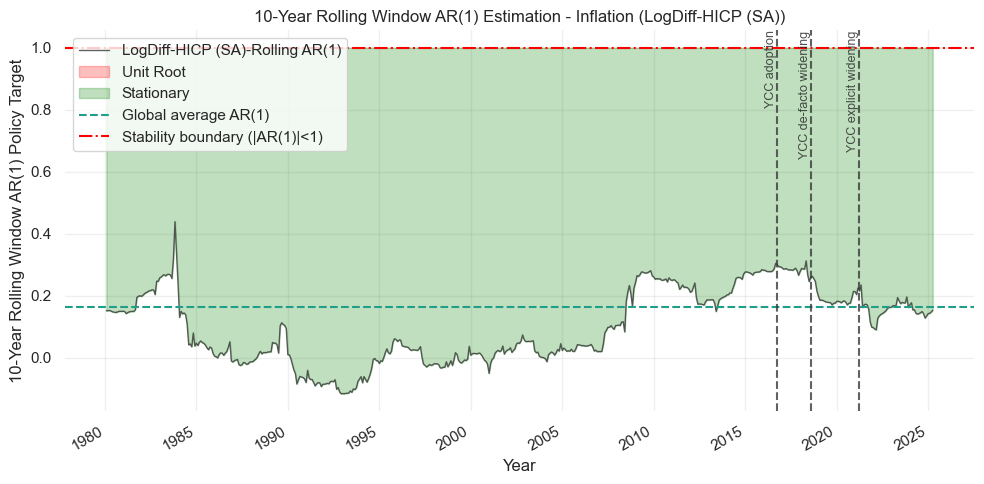

In [742]:
# Rolling Window AR(1) Process Estimation: Policy Target (LogDiff-HICP (SA))

# df merging from AR(1) rolling estimates
df = pd.merge(pi_rollAR1, i_rollAR1, on="Time", how="outer")
df = df.reset_index()
df["Time"] = pd.to_datetime(df["Time"]) 
df = df.set_index("Time")
core_variables = ["LogDiff-HICP (SA)-Rolling AR(1)"]
palette = ["#1F9E89",]

fig, ax = plt.subplots(figsize=(10, 5))

# Plot set-up 
for var, col in zip(core_variables, palette):
    ax.plot(
        df.index,
        df[var],
        label=f"{var}",
        linewidth=1,
        color = "#393939", 
        alpha = 0.8
        )
    
# Stationarity regions 
# (!!!) Where Operator to diferentiate the areas
ax.fill_between(df.index, df["LogDiff-HICP (SA)-Rolling AR(1)"], 
                1, 
                where=(df["LogDiff-HICP (SA)-Rolling AR(1)"] >= 1), 
                color="#FF0000", 
                alpha=0.25, 
                label="Unit Root")
ax.fill_between(df.index, 
                df["LogDiff-HICP (SA)-Rolling AR(1)"], 
                1, 
                where=(df["LogDiff-HICP (SA)-Rolling AR(1)"] < 1), 
                color="green", 
                alpha=0.25, 
                label="Stationary")

# Average AR(1) over the whole sample
# (!!!) I just take the value from previous computations
ax.axhline(
    0.16447832554317743,
    color="#1F9E89",
    lw=1.5,
    ls = "--",
    label="Global average AR(1)"
) 
# Stationarity Boundary
ax.axhline(
    1,
    color="#FF0000",
    lw=1.5,
    ls = "-.",
    label="Stability boundary (|AR(1)|<1)"
) 

# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1],
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1],
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1],
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"10-Year Rolling Window AR(1) Estimation - Inflation (LogDiff-HICP (SA))")
ax.set_xlabel("Year")
ax.set_ylabel(f"10-Year Rolling Window AR(1) Policy Target")
ax.grid(True, alpha=0.3)
ax.legend()

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

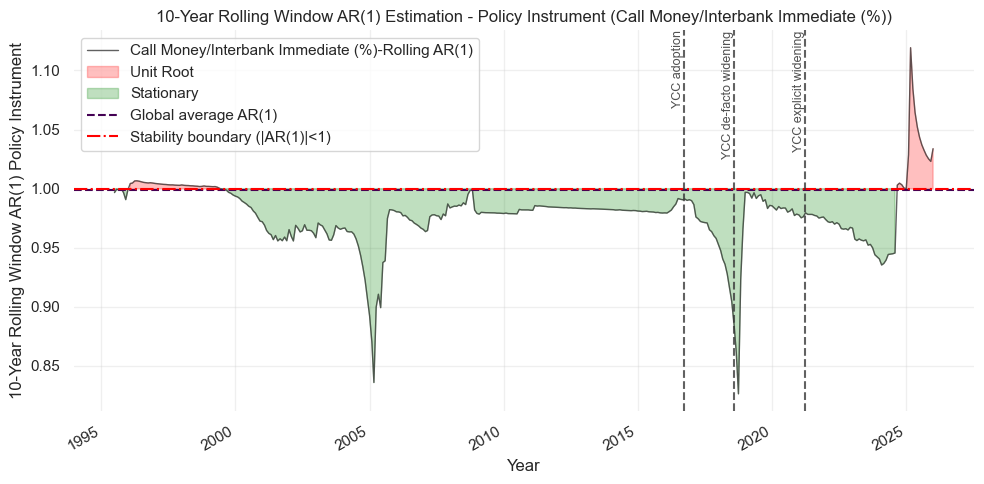

In [743]:
# Rolling Window AR(1) Estimation: Policy Instrument (Call Money/Interbank Immediate (%)) 

# df merging from AR(1) rolling estimates
df = pd.merge(pi_rollAR1, i_rollAR1, on="Time", how="outer")
df = df.reset_index()
df["Time"] = pd.to_datetime(df["Time"]) 
df = df.set_index("Time")
core_variables = ["Call Money/Interbank Immediate (%)-Rolling AR(1)"]
palette = ["#440154"]

fig, ax = plt.subplots(figsize=(10, 5))

# Plot set-up 
for var, col in zip(core_variables, palette):
    ax.plot(
        df.index,
        df[var],
        label=f"{var}",
        linewidth=1,
        color = "#393939",
        alpha = 0.8
        )
    
# Stationarity regions 
# (!!!) Where Operator to diferentiate the areas
ax.fill_between(df.index, df["Call Money/Interbank Immediate (%)-Rolling AR(1)"], 
                1, 
                where=(df["Call Money/Interbank Immediate (%)-Rolling AR(1)"] >= 1), 
                color="#FF0000", 
                alpha=0.25, 
                label="Unit Root")
ax.fill_between(df.index, 
                df["Call Money/Interbank Immediate (%)-Rolling AR(1)"], 
                1, 
                where=(df["Call Money/Interbank Immediate (%)-Rolling AR(1)"] < 1), 
                color="green", 
                alpha=0.25, 
                label="Stationary")

# Average AR(1) over the whole sample
# (!!!) I just take the value from previous computations
ax.axhline(
    0.9984573026699713,
    color="#440154",
    lw=1.5,
    ls = "--",
    label="Global average AR(1)"
) 
# Stationarity Boundary
ax.axhline(
    1,
    color="#FF0000",
    lw=1.5,
    ls = "-.",
    label="Stability boundary (|AR(1)|<1)"
) 

# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1],
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1],
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1],
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"10-Year Rolling Window AR(1) Estimation - Policy Instrument (Call Money/Interbank Immediate (%))")
ax.set_xlabel("Year")
ax.set_ylabel(f"10-Year Rolling Window AR(1) Policy Instrument")
ax.grid(True, alpha=0.3)
ax.legend()

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### **9) 3-YEAR ROLLING WINDOW AR(1) INFLATION**

In [744]:
# 3-Year Rolling Window Deterministic Trend - Inflation (LogDiff-HICP (SA))
# (!!!) Same structure as for 10-Year Rolling Window 
# Inflation (pi)
pi = jp_core_trans_df["LogDiff-HICP (SA)"].dropna()

# Window 
# (!!!) 36 lags window, given monthly frequency, 3 years are reached by 36 lags
window_3 = 36

g_list, date_list = [], []

# Rolling-Window Deterministic Trend 
# (!!!) We extract one chunk at a time (chunk)
for end_window in range(window_3, len(pi)):
    pi_window = pi.iloc[end_window - window_3 : end_window]
    y = pi_window.values
# (!!!) RHS is a deterministic time trend t = 0,1,...,35 - NOT the lagged series
    t = np.arange(len(y))
# (!!!) Core difference from before, function of time, not function on pi_t-1
    X = sm.add_constant(t)
    res = sm.OLS(y, X).fit()
# (!!!) params[1] = g (trend slope), not persistence
    g_list.append(res.params[1])
    date_list.append(pi.index[end_window])

pi_rolltrend = pd.DataFrame({
    "Time"    : date_list,
    "LogDiff-HICP (SA) - Rolling g (Time Trend)": g_list
}).set_index("Time")
pi_rolltrend

,LogDiff-HICP (SA) - Rolling g (Time Trend)
Time,
1973-02-01,-0.003553
1973-03-01,0.003819
1973-04-01,0.120980
1973-05-01,0.144520
1973-06-01,0.203092
...,...
2024-12-01,-0.028285
2025-01-01,-0.029600
2025-02-01,-0.047738


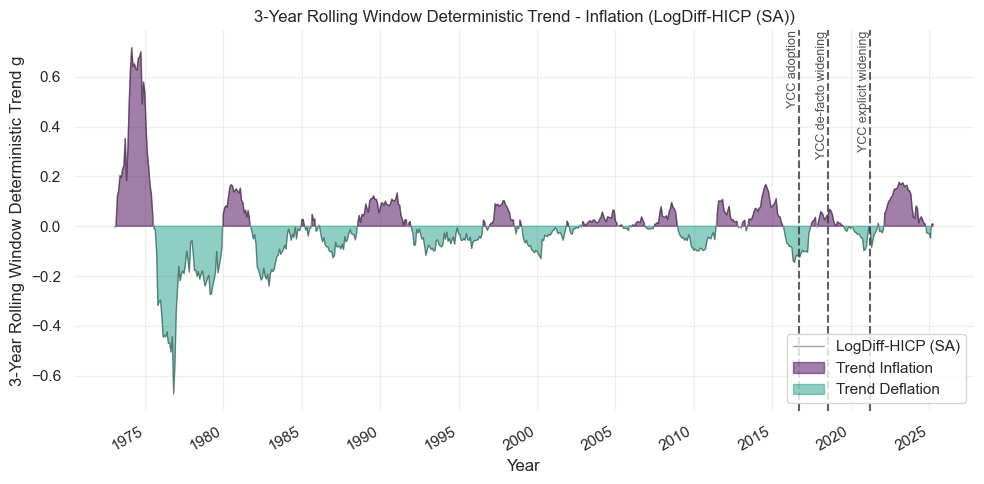

In [745]:
# 3-Year Rolling Window Deterministic Trend Plotting - Policy Target (LogDiff-HICP (SA))

# Rolling Time Trend df
df = pi_rolltrend.copy()
df = df.reset_index()
df["Time"] = pd.to_datetime(df["Time"]) 
df = df.set_index("Time")
core_variables = ["LogDiff-HICP (SA) - Rolling g (Time Trend)"]
palette = ["#1F9E89",]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df.index, 
        df["LogDiff-HICP (SA) - Rolling g (Time Trend)"], 
        color="#393939", 
        lw=0.9, 
        alpha=0.5,
        label=f"LogDiff-HICP (SA)"
        )
    
# Trend type regions 
# (!!!) Where Operator to diferentiate the areas
ax.fill_between(df.index, df["LogDiff-HICP (SA) - Rolling g (Time Trend)"], 
                0, 
                where=(df["LogDiff-HICP (SA) - Rolling g (Time Trend)"] >= 0), 
                color="#440154", 
                alpha=0.5, 
                label="Trend Inflation")
ax.fill_between(df.index, 
                df["LogDiff-HICP (SA) - Rolling g (Time Trend)"], 
                0, 
                where=(df["LogDiff-HICP (SA) - Rolling g (Time Trend)"] < 0), 
                color="#1F9E89", 
                alpha=0.5, 
                label="Trend Deflation")

# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1],
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1],
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1],
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Time Fix
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# General settings 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title(f"3-Year Rolling Window Deterministic Trend - Inflation (LogDiff-HICP (SA))")
ax.set_xlabel("Year")
ax.set_ylabel(f"3-Year Rolling Window Deterministic Trend g")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

# (!!!) autofmt_xdate() goes on fig not on ax
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### **10) AR(1) & g(trend) CORRELATION**

In [746]:
# Deterministic Trend on Unit Root Subperiods - Policy Target (LogDiff-HICP (SA))
# (!!!) We just need to see whether unit root periods from rolling AR(1) plot (phi_1 ≈ 1) are visually correlated to  pick rising and declining subperiods within those periods
# (!!!) We consider period of increasing AR(1), not close to 1 at all, in recent times near pivotal monetary policy chances in Japan

# YCC Adoption - Trend subperiod 
# (!!!) g > 0?, as we have no subperiod with unitroot close to 1 for inflation, we check what's the trend in recent times
# (!!!) In this case we check whether YCC has been succesfull in targetting inflation (excluding covid)
# (!!!) 2016-09 - 2020-01
ycc_adoption_start = "2016-09"
ycc_adoption_end   = "2020-01"

# Mask filter from start to end 
sub_ycc  = pi[ycc_adoption_start:ycc_adoption_end]
# Number of periods
t_ycc    = np.arange(len(sub_ycc))
# Regressor
X_ycc    = sm.add_constant(t_ycc)
# OLS
res_ycc  = sm.OLS(sub_ycc.values, X_ycc).fit()
# (!!!) We save params, a=constant and g=coefficient
a_ycc, g_ycc = res_ycc.params[0], res_ycc.params[1]

# Post-Financial Crisis Aftermath
# (!!!) 2008-01 - 2013-01
fin_crisis_start = "2008-01"
fin_crisis_end   = "2013-01"

sub_crisis  = pi[fin_crisis_start:fin_crisis_end]
t_crisis    = np.arange(len(sub_crisis))
X_crisis    = sm.add_constant(t_crisis)
res_crisis  = sm.OLS(sub_crisis.values, X_crisis).fit()
a_crisis, g_crisis = res_crisis.params[0], res_crisis.params[1]

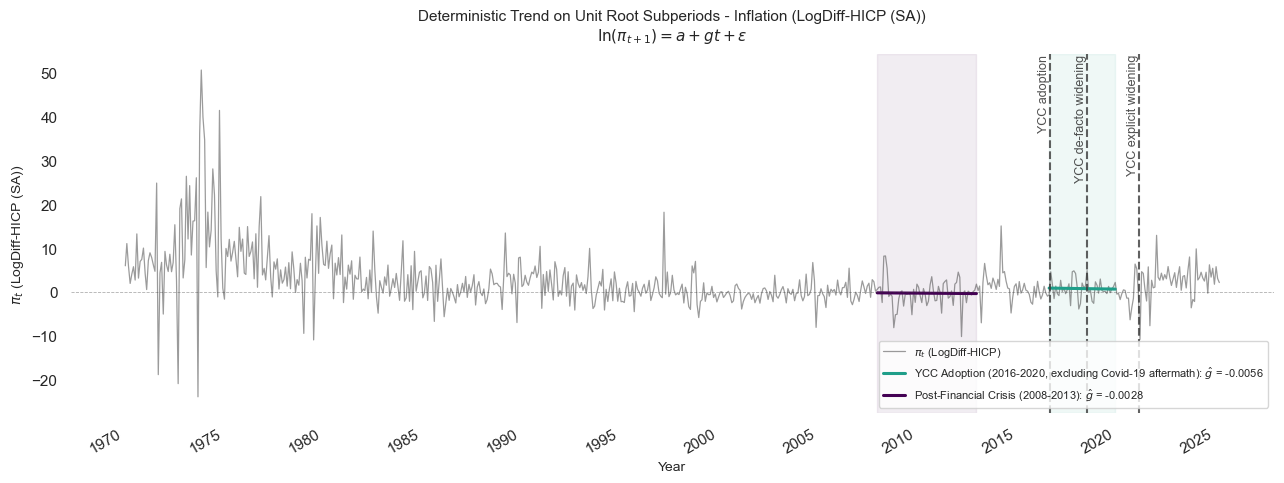

In [747]:
# Deterministic Trend on Unit Root Subperiods Plotting - Policy Target (LogDiff-HICP (SA))
# (!!!) We just need to see whether unit root periods from rolling AR(1) plot (phi_1 ≈ 1) are visually correlated to  pick rising and declining subperiods within those periods
# (!!!) We consider period of increasing AR(1), not close to 1 at all, in recent times near pivotal monetary policy chances in Japan
# Inflation LogDiff-HICP (SA)
pi = jp_core_trans_df["LogDiff-HICP (SA)"].dropna()

# General Settings
fig, ax = plt.subplots(figsize=(13, 5))

# Plotting
# (!!!) Inflation overtime plotting 
ax.plot(pi.index, 
        pi.values, 
        color="#393939", 
        lw=0.9, 
        alpha=0.5,
        label=r"$\pi_t$ (LogDiff-HICP)")

# YCC Adoption (2016-2020) inflation trend line
fitted_r = a_ycc + g_ycc * t_ycc
ax.plot(sub_ycc.index, fitted_r, color="#1F9E89", lw=2.2,
        label=fr"YCC Adoption (2016-2020, excluding Covid-19 aftermath): $\hat{{g}}$ = {g_ycc:.4f}")
ax.axvspan(sub_ycc.index[0], sub_ycc.index[-1], color="#1F9E89", alpha=0.07)

# Financial Crisis (2008-2013) inflation trend line
fitted_d = a_crisis + g_crisis * t_crisis
ax.plot(sub_crisis.index, fitted_d, color="#440154", lw=2.2,
        label=fr"Post-Financial Crisis (2008-2013): $\hat{{g}}$ = {g_crisis:.4f}")
# (!!!) Span Function
ax.axvspan(sub_crisis.index[0], sub_crisis.index[-1], color="#440154", alpha=0.07)

ax.axhline(0, color="#393939", lw=0.6, linestyle="--", alpha=0.4)

# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1],
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1],
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1],
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Plotting Cosmetics
# (!!!) Mix f with r, cuz the title can be in normalized string while for the formula needs to be in unicode
ax.set_title(f"Deterministic Trend on Unit Root Subperiods - Inflation (LogDiff-HICP (SA))"
             "\n"
             r"$\ln(\pi_{t+1}) = a + gt + \varepsilon$",
             fontsize=11, pad=10)
# Axis Label 
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel(r"$\pi_t$ (LogDiff-HICP (SA))", fontsize=10)
ax.legend(fontsize=8, loc="lower right")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


### **11) POST-YCC ADOPTION UNIT-ROOT TESTING**

In [748]:
# Unit-root Testing Post YCC - Adfuller Test 
# Drop non-numeric columns and handle missing data
# (!!!) Exactly as before, but constrained to post-ycc adoption
df = jp_core_hybrid_df.copy()
df = df[df["Time"] >= "2016-01"]
jp_core_hybrid_numeric = df.drop(columns=["Country", "Time"]).dropna()

# (!!!) We need to initialize the results as empty list before execuding the test
results = []

for col in jp_core_hybrid_numeric.columns:
    series = jp_core_hybrid_numeric[col]

# As before, we extract the AR(1) coefficients
    ar1_postycc = series.autocorr(lag=1)

# Augmented Dickey-Fuller (ADF) unit root test 
    adf_result_postycc = adfuller(series, autolag="AIC")
    adf_stat_postycc = adf_result_postycc[0]
    p_value_postycc = adf_result_postycc[1]
    crit_values_postycc = adf_result_postycc[4]

    results.append({
        "Variable": col,
        "ADF Statistic": adf_stat_postycc,
        "p-value": p_value_postycc,
        "Stationary - Absence of unit-root (HP1)": "Yes" if p_value_postycc < 0.05 else "No"
    })

jp_adf_postycc_df = pd.DataFrame(results)
jp_adf_postycc_df

,Variable,ADF Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-HICP (SA),-1.503173,0.531941,No
1,Call Money/Interbank Immediate (%),1.988627,0.998658,No
2,10-Year Gov Bond Yields (%),2.233415,0.998909,No


In [749]:
# Unit-root Testing Post-YCC - Phillips-Perron Test 
# (!!!) We need to initialize the results as empty list before execuding the test
pp_results = []

for col in jp_core_hybrid_numeric.columns:
    series = jp_core_hybrid_numeric[col].dropna()
    
# Phillips–Perron test 
# (!!!) From arch instead of stats.models is much smoother
    test_postycc = PhillipsPerron(series)
    pp_results.append({
        "Variable": col,
        "PP Statistic": test_postycc.stat,
        "p-value": test_postycc.pvalue,
        "Stationary - Absence of unit-root (HP1)": "Yes" if test_postycc.pvalue < 0.05 else "No"
    })

jp_pp_postycc_df = pd.DataFrame(pp_results)
jp_pp_postycc_df

,Variable,PP Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-HICP (SA),-10.023050,1.659449e-17,Yes
1,Call Money/Interbank Immediate (%),3.005264,1.000000e+00,No
2,10-Year Gov Bond Yields (%),1.877362,9.984907e-01,No


### **12) LAGGED CROSS-CORRELATION**

In [750]:
# Lagged Correlation between lagged policy target and policy instrument 
# (!!!) We extract the corellation coefficient between i_t and pi_t+2, pi_t+1, pi, pi_t-1, pi_t-2
df = jp_core_hybrid_df.copy()

# Infation
pi = df["LogDiff-HICP (SA)"]
# Policy Target
i = df["Call Money/Interbank Immediate (%)"]

# Lagged Cross-correlation
lags = [-2, -1, 0, 1, 2]
i_lagpi_corr = pd.DataFrame(index=["Corr(i_t, π_{t+k})"], columns=[f"t{k}" for k in lags])
# (!!!) We need to distinguish the types of lags we have, above or below 0, otherwise it makes the lopp crashes 
for k in lags:
# Past lags     
    if k < 0:
        corr = i.corr(pi.iloc[:k])
# Future lags        
    elif k > 0:
        corr = i.iloc[k:].corr(pi.iloc[:-k])
# Instant correlation, basically i_t and pi_t        
    else:
        corr = i.corr(pi)
    i_lagpi_corr[f"t{k}"] = corr

i_lagpi_corr.round(4)
i_lagpi_corr

,t-2,t-1,t0,t1,t2
"Corr(i_t, π_{t+k})",0.199305,0.198786,0.1985,0.198937,0.206121


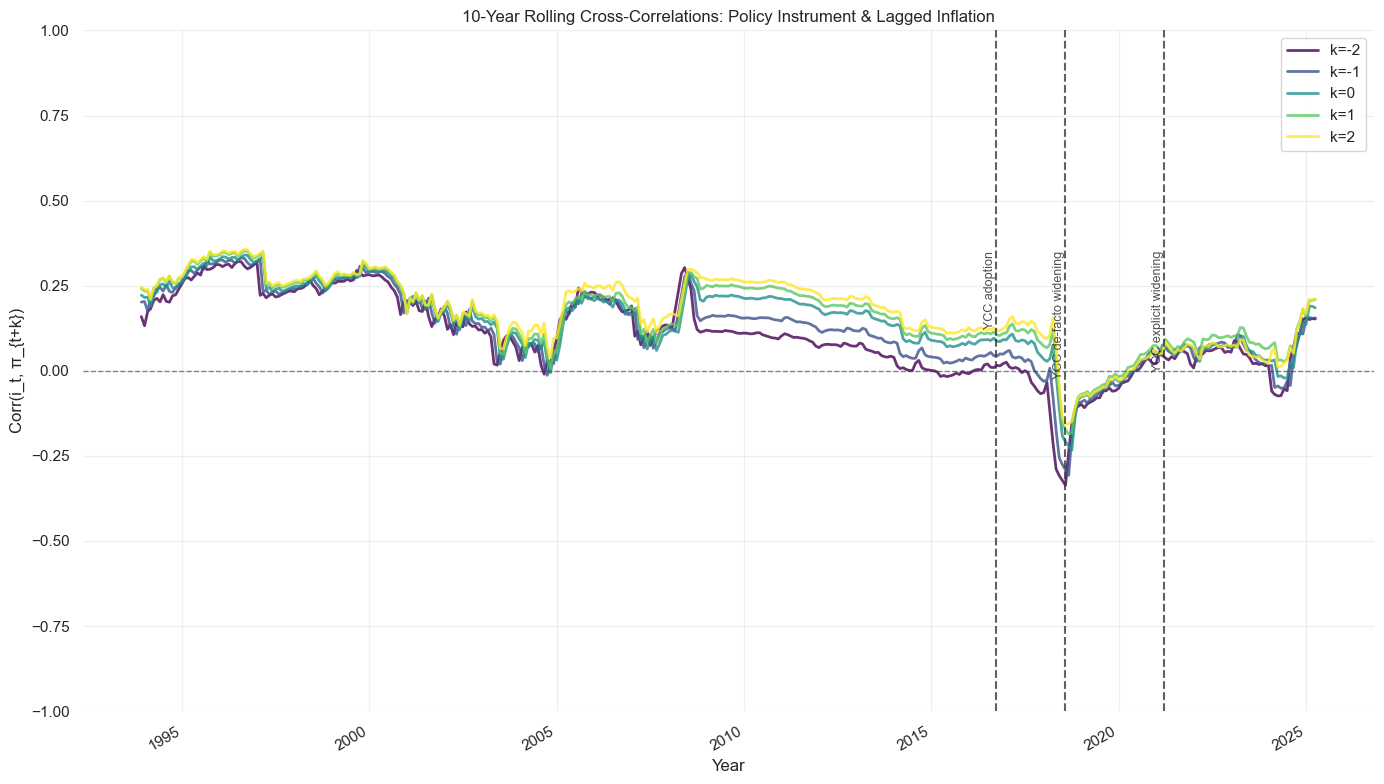

In [751]:
# 10-Year Rolling Cross-Correlations Plotting between Policy Target and POlicy Instrument 

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
df = jp_core_hybrid_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 

# Infation
pi = df["LogDiff-HICP (SA)"].dropna()
# Policy Target
i = df["Call Money/Interbank Immediate (%)"].dropna()

# (!!!) 10-year rolling correlations, same approach as we did for AR(1) Rolling Window
# (!!!) 10 years correpsond to 120 lags in monthly frequency 
window = 120 
# (!!!) Lags like before 
lags = [-2, -1, 0, 1, 2]
# Palette
palette = ["#440154", "#3B528B", "#21908C", "#5DC863", "#FDE725"]

# Correlation loop
# (!!!) We start form the outside, from lags to windows
# (!!!) We need to adjust date alignment
for idx, k in enumerate(lags):
    if k == 0:
        corr_series = i.rolling(window, min_periods=window//2).corr(pi)
    elif k < 0:
        corr_series = i.rolling(window, min_periods=window//2).corr(pi.shift(k))
    else:
        corr_series = i.shift(-k).rolling(window, min_periods=window//2).corr(pi)

    ax.plot(corr_series.index, corr_series.values, linewidth=2, 
            color=palette[idx], label=f"k={k}", alpha=0.8)

# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10-Year Rolling Cross-Correlations: Policy Instrument & Lagged Inflation")
ax.set_xlabel("Year")
ax.set_ylabel("Corr(i_t, π_{t+k})")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(-1, 1)
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


### **13) FIRST ORDER SINGLE INPUT SINGLE OUTPUT MODEL**

In [752]:
# 10-year rolling window first-order Single Input Single Output (SISO) Model 
# (!!!) π_t = A π_{t-1} + B i_{t-1} + ε_t
df = jp_core_hybrid_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")

# Inflation 
pi = df["LogDiff-HICP (SA)"].dropna()
# Policy Instrument 
i  = df["Call Money/Interbank Immediate (%)"].dropna()

# (!!!) 10-year rolling correlations, same approach as we did for AR(1) Rolling Window
# (!!!) 10 years correpsond to 120 lags in monthly frequency
window = 120  
results = []

# Estimation loop
# (!!!) We need to adjust date alignment, and window like before
# (!!!) Chunk Extraction (120)
for start in range(window, len(pi)):



# Single Input Single Output Model: i_t-1 = Fi_{π_t-1} + e_t
    i_tm1 = i.iloc[start-window:start]   
# Regressors: pi_t-1 and i_t-1
    X = pd.DataFrame({"pi_t-1": pi.shift(1).iloc[start-window:start]}).dropna()
    X = sm.add_constant(X)
    i_tm1  = i_tm1.loc[X.index] 
# Model Estimation (OLS)
    model = sm.OLS(i_tm1, X).fit()
# (!!!) We need to get F, coeff of pi_t-1
    F = model.params["pi_t-1"]
# Residuals AR(1): u_t-1 = rho u_t-2 + n_t
    e_tm1 = model.resid.dropna()
    e_gamma = e_tm1.autocorr(lag=1)




# Single Input Single Output Model: π_t = A π_{t-1} + B i_{t-1} + u_t
# Dependent: pi_t
    pi_t = pi.iloc[start-window:start]
# Regressors: pi_t-1 and i_t-1
    X = pd.concat([pi.shift(1).iloc[start-window:start], 
                   i.shift(1).iloc[start-window:start]], axis=1).dropna()
    X.columns = ["pi_t-1", "i_t-1"]
# (!!!) Index allignment
    pi_t = pi_t.loc[X.index]                   
    X = sm.add_constant(X)

# Model Estimation (OLS)
    model = sm.OLS(pi_t, X).fit()
# (!!!) We need to get A and B, which are coeff1 and coeff2    
    A = model.params["pi_t-1"]
    B = model.params["i_t-1"]
    
# Residuals AR(1): u_t-1 = rho u_t-2 + n_t
    u_t = model.resid.dropna()
    u_rho = u_t.autocorr(lag=1)
    
    results.append({
        "Time": pi.index[start],
        "A": A, "B": B, "F": F,
        "e_gamma (i_t-1)": e_gamma, "u_rho (π_t)": u_rho
    })

results_df = pd.DataFrame(results).round(4)
abf_10roll_df = results_df.copy()
abf_10roll_df

,Time,A,B,F,e_gamma (i_t-1),u_rho (π_t)
0,1999-01-01,-0.0857,0.3488,0.1826,0.9338,-0.0066
1,1999-02-01,-0.0707,0.3669,0.1887,0.9282,-0.0072
2,1999-03-01,-0.0608,0.3793,0.1962,0.9232,0.0005
3,1999-04-01,-0.0534,0.3833,0.2088,0.9140,-0.0101
4,1999-05-01,-0.0657,0.3672,0.2127,0.9137,-0.0230
...,...,...,...,...,...,...
311,2024-12-01,0.1293,3.2967,0.0024,0.9344,-0.0008
312,2025-01-01,0.1319,4.8586,0.0030,0.9350,-0.0029
313,2025-02-01,0.1295,4.2941,0.0041,0.9291,-0.0021
314,2025-03-01,0.1262,6.2013,0.0042,0.9253,-0.0014


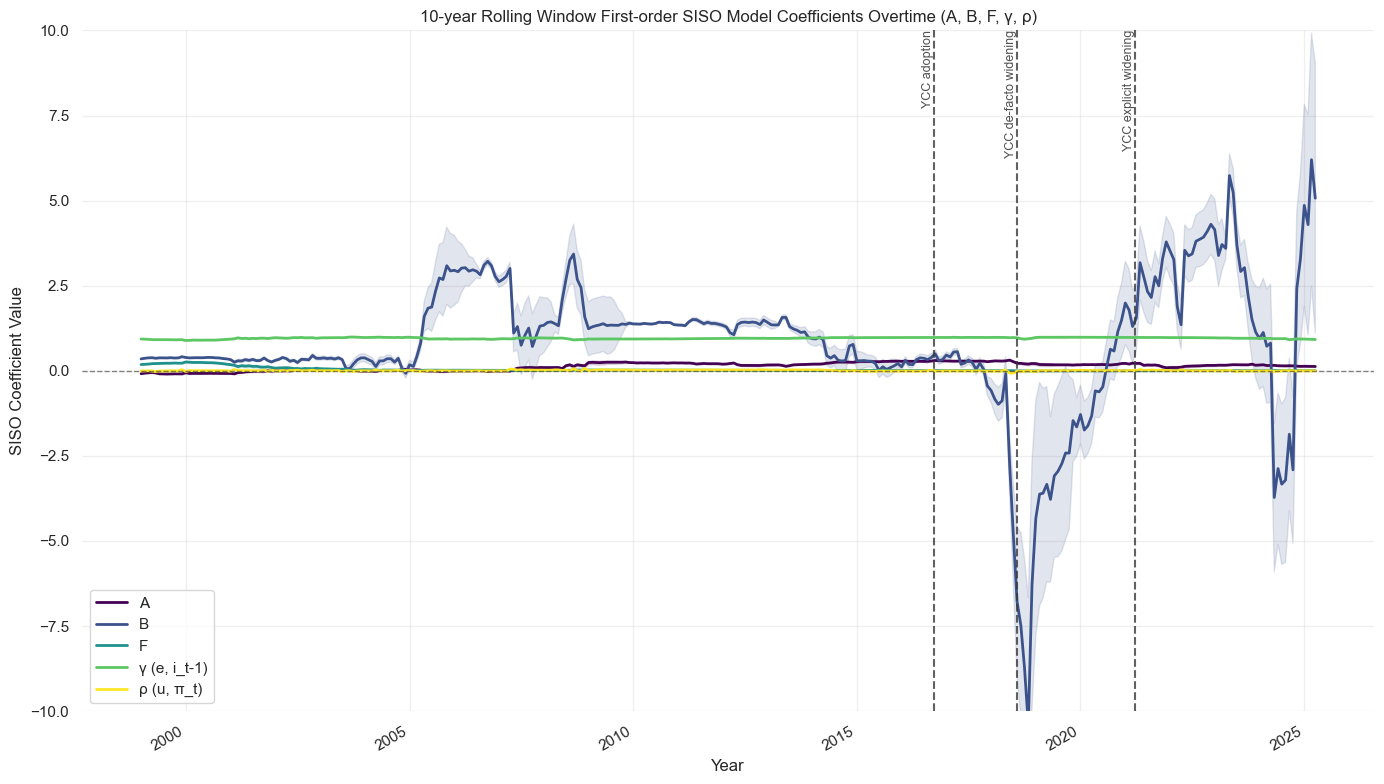

In [753]:
# 10-year rolling window first-order Single Input Single Output (SISO) Model Overtime Plotting
# (!!!) 10-year rolling coefficients from SISO, same approach as we did for AR(1) Rolling Window

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
df = abf_10roll_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 

# A
A = df["A"].dropna()
# B
B = df["B"].dropna()
# F
F = df["F"].dropna()
# e_gamma (i_t-1)
e_gamma = df["e_gamma (i_t-1)"].dropna()
# u_rho (π_t)
u_rho = df["u_rho (π_t)"].dropna()

# Plotting (A, B, F, e_gamma, u_rho)
ax.plot(df.index, A, linewidth=2, 
        color="#440154", label=f"A",)
ax.fill_between(A.index, A - A.rolling(12).std(), A + A.rolling(12).std(),
                color="#440154", alpha=0.15)
ax.plot(df.index, B, linewidth=2, 
        color="#3B528B", label=f"B")
ax.fill_between(B.index, B - B.rolling(12).std(), B + B.rolling(12).std(),
                color="#3B528B", alpha=0.15)
ax.plot(df.index, F, linewidth=2, 
        color="#21908C", label=f"F")
ax.fill_between(F.index, F - F.rolling(12).std(), F + F.rolling(12).std(),
                color="#21908C", alpha=0.15)
ax.plot(df.index, e_gamma, linewidth=2, 
        color="#5DC863", label=f"γ (e, i_t-1)")
ax.fill_between(e_gamma.index, e_gamma - e_gamma.rolling(12).std(), e_gamma + e_gamma.rolling(12).std(),
                color="#5DC863", alpha=0.15)
ax.plot(df.index, u_rho, linewidth=2, 
        color="#FDE725", label=f"ρ (u, π_t)")
ax.fill_between(u_rho.index, u_rho - u_rho.rolling(12).std(), u_rho + u_rho.rolling(12).std(),
                color="#FDE725", alpha=0.15)

# Instability Regions |A+BF|>1
common_idx = A.index.intersection(B.index).intersection(F.index)
A_c = A.loc[common_idx]
B_c = B.loc[common_idx]
F_c = F.loc[common_idx]
condition = abs(A_c + B_c * F_c) > 1
in_region = False
first_span = True  
for date, val in condition.items():
    if val and not in_region:
        region_start = date
        in_region = True
    elif not val and in_region:
        if first_span:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25, label="Instability Region (|A+BF|>1)")
            first_span = False  
        else:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25)
        in_region = False
if in_region:
    ax.axvspan(region_start, common_idx[-1], color="#FF0000", alpha=0.25)


# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10-year Rolling Window First-order SISO Model Coefficients Overtime (A, B, F, γ, ρ)")
ax.set_xlabel("Year")
ax.set_ylabel("SISO Coefficient Value")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)
# Rescailing
ax.set_ylim(-10, 10)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### **14) AR(1) & SISO |A+BF| COMPARISON**

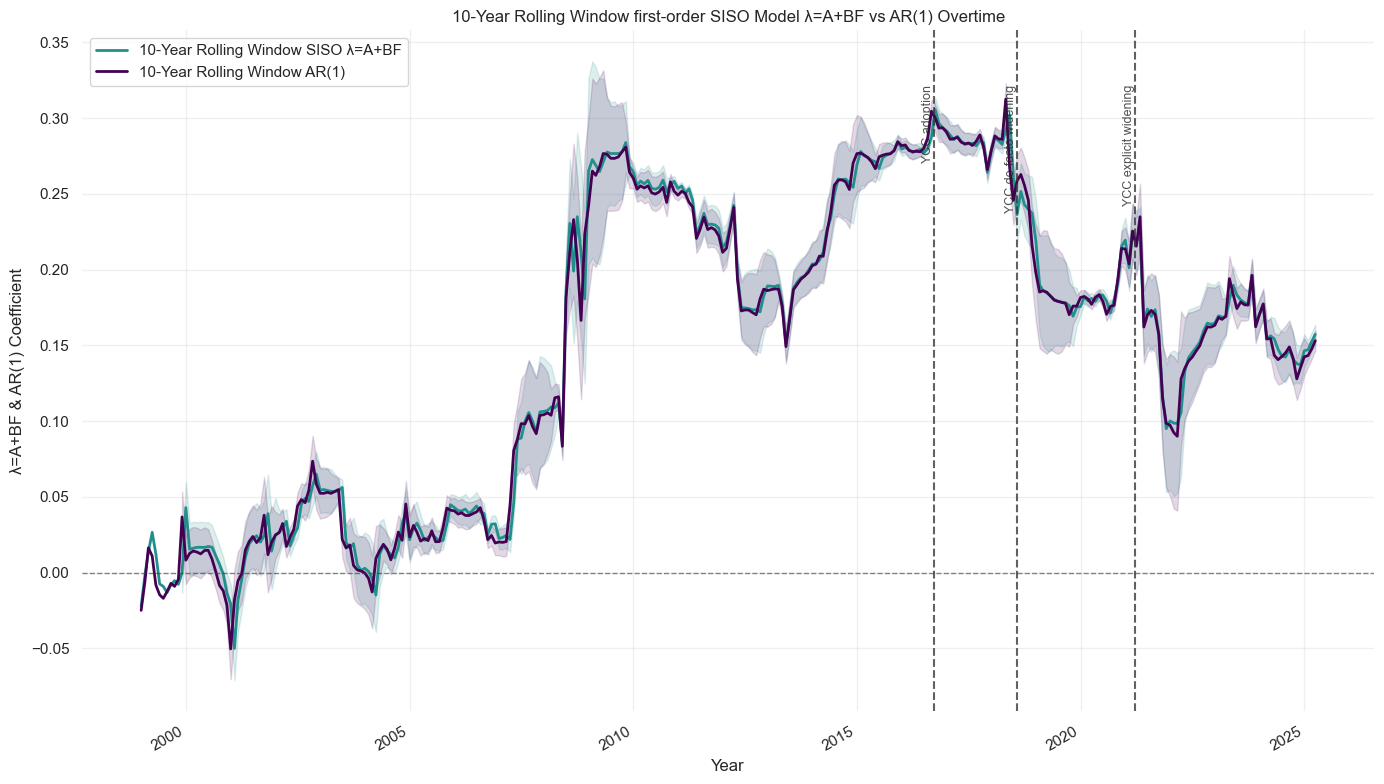

In [754]:
# 10-year rolling window first-order SISO Model Lambda vs AR(1) Overtime Plotting
# (!!!) 10-year rolling coefficients from SISO, same approach as we did for AR(1) Rolling Window

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")


# Plotting (AR(1) & lambda)
# SISO Lambda
df = abf_10roll_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 
# A
A = df["A"].dropna()
# B
B = df["B"].dropna()
# F
F = df["F"].dropna()
# lambda
df["lambda"] = A + B*F
lambda_SISO = df["lambda"].dropna()
ax.plot(df.index, lambda_SISO, linewidth=2, 
        color="#21908C", label=f"10-Year Rolling Window SISO λ=A+BF",)
ax.fill_between(lambda_SISO.index, lambda_SISO - lambda_SISO.rolling(12).std(), lambda_SISO + lambda_SISO.rolling(12).std(),
                color="#21908C", alpha=0.15)

# AR(1)
# (!!!) Filter date from 1990 and on, common start
df = pi_rollAR1.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 
df = df[df.index >= "1999-01-01"]
AR1 = df["LogDiff-HICP (SA)-Rolling AR(1)"].dropna()
ax.plot(df.index, AR1, linewidth=2, 
        color="#440154", label=f"10-Year Rolling Window AR(1)",)
ax.fill_between(AR1.index, AR1 - AR1.rolling(12).std(), AR1 + AR1.rolling(12).std(),
                color="#440154", alpha=0.15)




# Instability Regions |A+BF|>1
common_idx = A.index.intersection(B.index).intersection(F.index)
A_c = A.loc[common_idx]
B_c = B.loc[common_idx]
F_c = F.loc[common_idx]
condition = abs(A_c + B_c * F_c) > 1
in_region = False
first_span = True  
for date, val in condition.items():
    if val and not in_region:
        region_start = date
        in_region = True
    elif not val and in_region:
        if first_span:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25, label="Instability Region (|A+BF|>1)")
            first_span = False  
        else:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25)
        in_region = False
if in_region:
    ax.axvspan(region_start, common_idx[-1], color="#FF0000", alpha=0.25)




# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10-Year Rolling Window first-order SISO Model λ=A+BF vs AR(1) Overtime")
ax.set_xlabel("Year")
ax.set_ylabel("λ=A+BF & AR(1) Coefficient")
ax.grid(True, alpha=0.3)
ax.legend()
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### **15) LUCAS CRITIQUE**

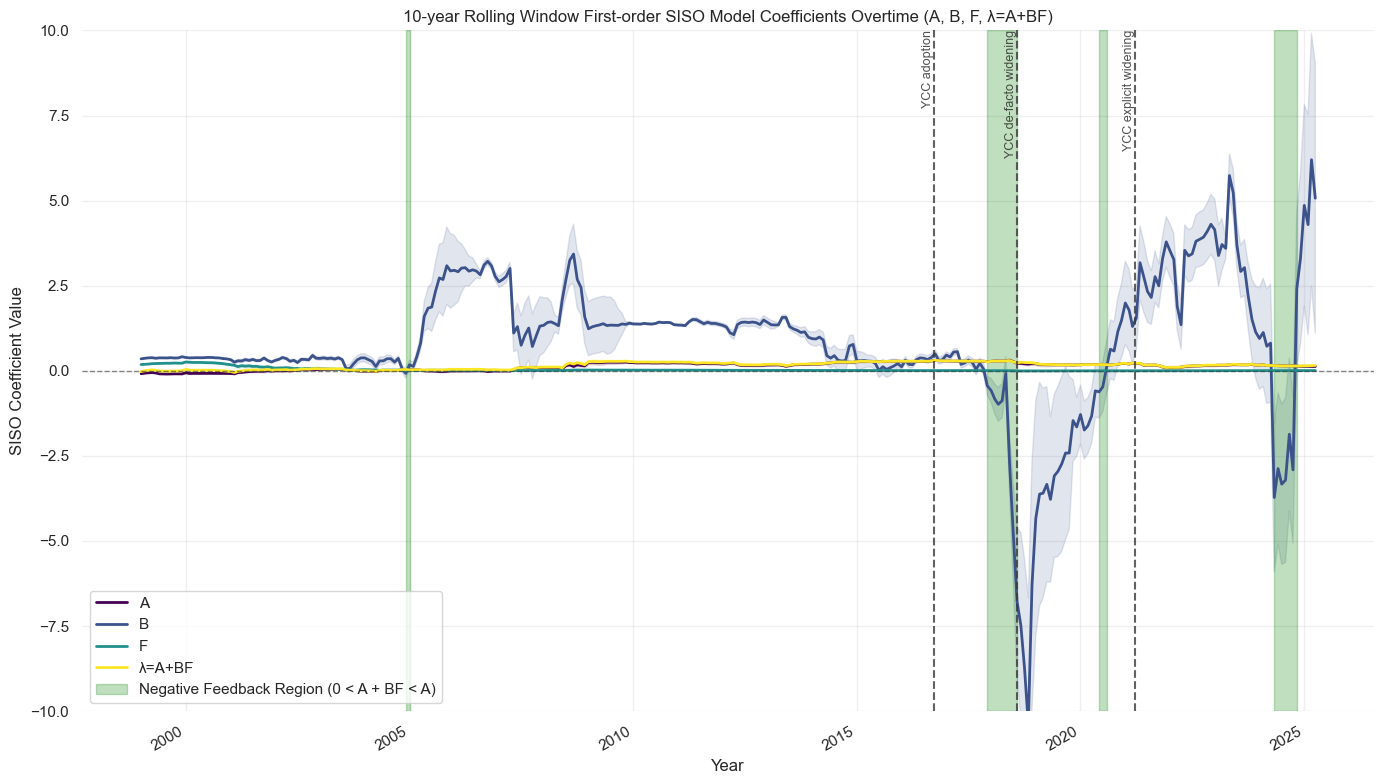

In [755]:
# 10-year rolling window first-order Single Input Single Output (SISO) Model Overtime Plotting - Lucas Critique
# (!!!) 10-year rolling coefficients from SISO, same approach as we did for AR(1) Rolling Window

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
df = abf_10roll_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 

# A
A = df["A"].dropna()
# B
B = df["B"].dropna()
# F
F = df["F"].dropna()
# lambda
df["lambda"] = A + B*F
lambda_SISO = df["lambda"].dropna()

# Plotting (A, B, F, e_gamma, u_rho)
ax.plot(df.index, A, linewidth=2, 
        color="#440154", label=f"A",)
ax.fill_between(A.index, A - A.rolling(12).std(), A + A.rolling(12).std(),
                color="#440154", alpha=0.15)
ax.plot(df.index, B, linewidth=2, 
        color="#3B528B", label=f"B")
ax.fill_between(B.index, B - B.rolling(12).std(), B + B.rolling(12).std(),
                color="#3B528B", alpha=0.15)
ax.plot(df.index, F, linewidth=2, 
        color="#21908C", label=f"F")
ax.fill_between(F.index, F - F.rolling(12).std(), F + F.rolling(12).std(),
                color="#21908C", alpha=0.15)
ax.plot(df.index, lambda_SISO, linewidth=2, 
        color="#FDE725", label=f"λ=A+BF",)
ax.fill_between(lambda_SISO.index, lambda_SISO - lambda_SISO.rolling(12).std(), lambda_SISO + lambda_SISO.rolling(12).std(),
                color="#FDE725", alpha=0.15)

# Negative Feedback Regions (0 < A + BF < A)
common_idx = A.index.intersection(B.index).intersection(F.index)
A_c = A.loc[common_idx]
B_c = B.loc[common_idx]
F_c = F.loc[common_idx]
condition = (0 < A_c + B_c * F_c) & (A_c + B_c * F_c < A_c)
in_region = False
first_span = True  
for date, val in condition.items():
    if val and not in_region:
        region_start = date
        in_region = True
    elif not val and in_region:
        if first_span:
            ax.axvspan(region_start, date, color="green", alpha=0.25, label="Negative Feedback Region (0 < A + BF < A)")
            first_span = False  
        else:
            ax.axvspan(region_start, date, color="green", alpha=0.25)
        in_region = False
if in_region:
    ax.axvspan(region_start, common_idx[-1], color="green", alpha=0.25)


# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10-year Rolling Window First-order SISO Model Coefficients Overtime (A, B, F, λ=A+BF)")
ax.set_xlabel("Year")
ax.set_ylabel("SISO Coefficient Value")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)
# Rescailing
ax.set_ylim(-10, 10)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### **16) SISO & AR(1) ANALYSIS WITH LOGDIFF POLICY INSTRUMENT**

In [756]:
# Autocorrelation coefficients AR(1)
# (!!!) jp_trans_df cleaning
jp_trans_df = pd.read_csv("Data/Transformed/jp_trans_df.csv")
# (!!!) We have to replace ±inf produced by log-diff on zero values before any computation
jp_trans_df.replace([np.inf, -np.inf], 0, inplace=True)
df = jp_trans_df[["Country", "Time", "LogDiff-HICP (SA)", "LogDiff-Call Money/Interbank Immediate (%)"]].dropna().copy()
# Drop non-numeric columns and rows with missing values
jp_transformed_numeric = df[["LogDiff-HICP (SA)", "LogDiff-Call Money/Interbank Immediate (%)"]]

# AR(1) autocorrelation for each variable
ar1_results = {}
for col in jp_transformed_numeric.columns:
    series = jp_transformed_numeric[col]

# (!!!) lag-1 autocorrelation
    ar1 = series.autocorr(lag=1)
    ar1_results[col] = ar1

# Better to create a dataframe to display the results
jp_ar1_logdiff_df = pd.DataFrame.from_dict(ar1_results, orient="index", columns=["AR(1)"])
jp_ar1_logdiff_df

,AR(1)
LogDiff-HICP (SA),0.152112
LogDiff-Call Money/Interbank Immediate (%),0.071820


In [757]:
# Unit-root Testing - Adfuller Test 
# (!!!) We have to replace ±inf produced by log-diff on zero values before any computation
df = jp_trans_df[["Country", "Time", "LogDiff-HICP (SA)", "LogDiff-Call Money/Interbank Immediate (%)"]].dropna().copy()
# Drop non-numeric columns and rows with missing values
jp_trans_numeric = df[["LogDiff-HICP (SA)", "LogDiff-Call Money/Interbank Immediate (%)"]]

# (!!!) We need to initialize the results as empty list before execuding the test
results = []

for col in jp_trans_numeric.columns:
    series = jp_trans_numeric[col]

# As before, we extract the AR(1) coefficients
    ar1 = series.autocorr(lag=1)

# Augmented Dickey-Fuller (ADF) unit root test 
    adf_result = adfuller(series, autolag="AIC")
    adf_stat = adf_result[0]
    p_value = adf_result[1]
    crit_values = adf_result[4]

    results.append({
        "Variable": col,
        "AR(1)": ar1,
        "ADF Statistic": adf_stat,
        "p-value": p_value,
        "Stationary - Absence of unit-root (HP1)": "Yes" if p_value < 0.05 else "No"
    })

jp_adf_logdiff_df = pd.DataFrame(results)
jp_adf_logdiff_df

,Variable,AR(1),ADF Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-HICP (SA),0.152112,-3.820628,2.703180e-03,Yes
1,LogDiff-Call Money/Interbank Immediate (%),0.071820,-5.648319,9.994161e-07,Yes


In [758]:
# Unit-root Testing - Phillips-Perron Test 
# (!!!) We need to initialize the results as empty list before execuding the test
pp_results = []

for col in jp_trans_numeric.columns:
    series = jp_trans_numeric[col].dropna()
    
# Phillips–Perron test 
# (!!!) From arch instead of stats.models is much smoother
    test = PhillipsPerron(series)
    pp_results.append({
        "Variable": col,
        "PP Statistic": test.stat,
        "p-value": test.pvalue,
        "Stationary - Absence of unit-root (HP1)": "Yes" if test.pvalue < 0.05 else "No"
    })

jp_pp_logdiff_df = pd.DataFrame(pp_results)
jp_pp_logdiff_df

,Variable,PP Statistic,p-value,Stationary - Absence of unit-root (HP1)
0,LogDiff-HICP (SA),-18.364116,2.224407e-30,Yes
1,LogDiff-Call Money/Interbank Immediate (%),-18.953072,0.000000e+00,Yes


In [759]:
# 10-year rolling window first-order Single Input Single Output (SISO) Model with LogDiff Policy Instrument
# (!!!) π_t = A π_{t-1} + B i_{t-1} + ε_t
# (!!!) We have to replace ±inf produced by log-diff on zero values before any computation
df = jp_trans_df[["Country", "Time", "LogDiff-HICP (SA)", "LogDiff-Call Money/Interbank Immediate (%)"]].dropna().copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")
# (!!!) Remember to drop nan, i lost 1h
df = df.dropna()

# Inflation 
pi = df["LogDiff-HICP (SA)"].dropna()
# Policy Instrument 
i = df["LogDiff-Call Money/Interbank Immediate (%)"].dropna()

# (!!!) 10-year rolling correlations, same approach as we did for AR(1) Rolling Window
# (!!!) 10 years correpsond to 120 lags in monthly frequency
window = 120  
results = []

# Estimation loop
# (!!!) We need to adjust date alignment, and window like before
# (!!!) Chunk Extraction (120)
for start in range(window, len(pi)):



# Single Input Single Output Model: i_t-1 = Fi_{π_t-1} + e_t
    i_tm1 = i.iloc[start-window:start]   
# Regressors: pi_t-1 and i_t-1
    X = pd.DataFrame({"pi_t-1": pi.shift(1).iloc[start-window:start]}).dropna()
    X = sm.add_constant(X)
    i_tm1  = i_tm1.loc[X.index] 
# Model Estimation (OLS)
    model = sm.OLS(i_tm1, X).fit()
# (!!!) We need to get F, coeff of pi_t-1
    F = model.params["pi_t-1"]
# Residuals AR(1): u_t-1 = rho u_t-2 + n_t
    e_tm1 = model.resid.dropna()
    e_gamma = e_tm1.autocorr(lag=1)




# Single Input Single Output Model: π_t = A π_{t-1} + B i_{t-1} + u_t
# Dependent: pi_t
    pi_t = pi.iloc[start-window:start]
# Regressors: pi_t-1 and i_t-1
    X = pd.concat([pi.shift(1).iloc[start-window:start], 
                   i.shift(1).iloc[start-window:start]], axis=1).dropna()
    X.columns = ["pi_t-1", "i_t-1"]
# (!!!) Index allignment
    pi_t = pi_t.loc[X.index]                   
    X = sm.add_constant(X)

# Model Estimation (OLS)
    model = sm.OLS(pi_t, X).fit()
# (!!!) We need to get A and B, which are coeff1 and coeff2    
    A = model.params["pi_t-1"]
    B = model.params["i_t-1"]
    
# Residuals AR(1): u_t-1 = rho u_t-2 + n_t
    u_t = model.resid.dropna()
    u_rho = u_t.autocorr(lag=1)
    
    results.append({
        "Time": pi.index[start],
        "A": A, "B": B, "F": F,
        "e_gamma (i_t-1)": e_gamma, "u_rho (π_t)": u_rho
    })

results_df = pd.DataFrame(results).round(4)
abf_10roll_logdiff_df = results_df.copy()
abf_10roll_logdiff_df

,Time,A,B,F,e_gamma (i_t-1),u_rho (π_t)
0,1995-08-01,-0.0212,11.3393,0.0032,0.2008,-0.0255
1,1995-09-01,-0.0213,10.8682,0.0033,0.2076,-0.0245
2,1995-10-01,-0.0173,10.6031,0.0039,0.2004,-0.0011
3,1995-11-01,0.0057,10.9276,0.0043,0.2574,-0.0125
4,1995-12-01,0.0084,10.4266,0.0037,0.2350,-0.0170
...,...,...,...,...,...,...
255,2024-12-01,0.3155,0.4844,0.0104,-0.1799,-0.0252
256,2025-01-01,0.3222,0.4516,0.0105,-0.1798,-0.0278
257,2025-02-01,0.3206,0.4575,0.0113,-0.1835,-0.0274
258,2025-03-01,0.3209,0.6922,0.0118,-0.1661,-0.0364


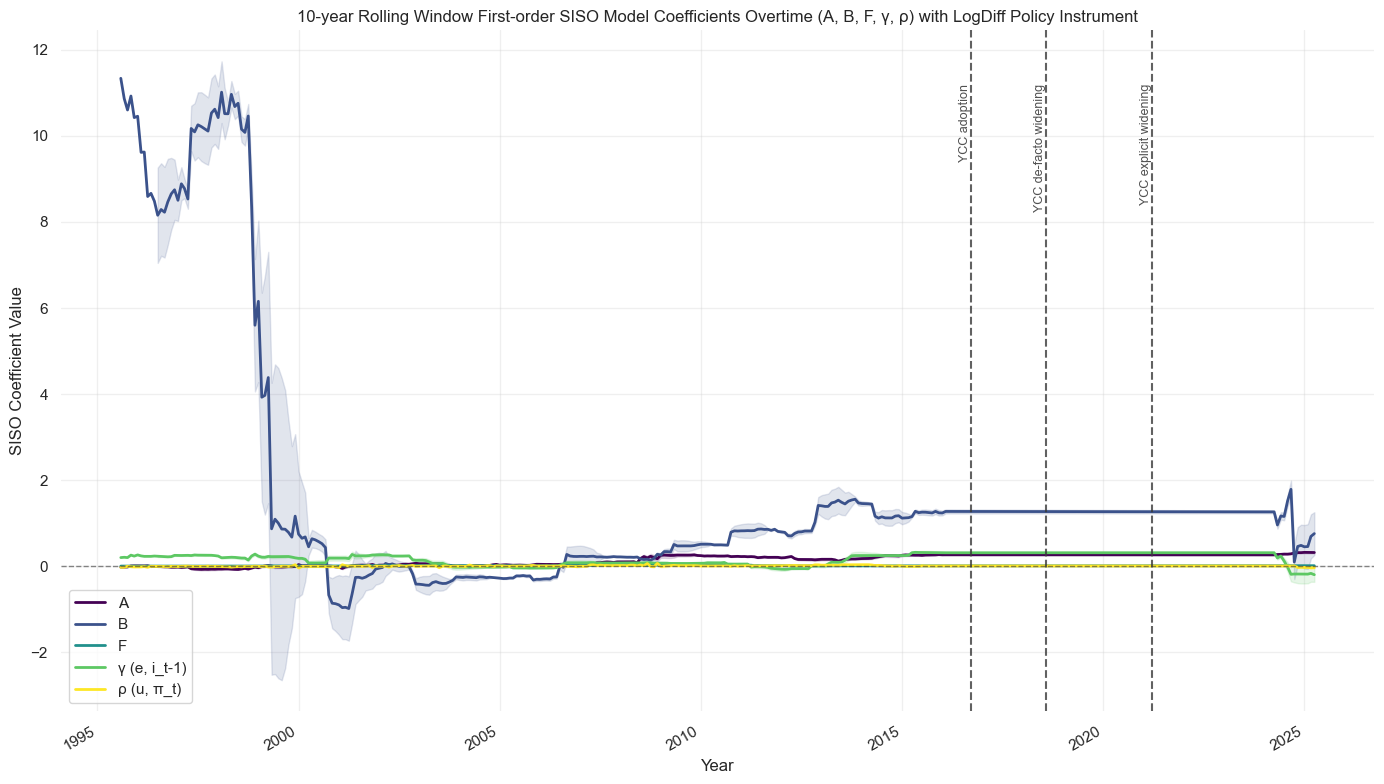

In [760]:
# 10-year rolling window first-order Single Input Single Output (SISO) Model Overtime Plotting with LogDiff Policy Instrument
# (!!!) 10-year rolling coefficients from SISO, same approach as we did for AR(1) Rolling Window

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
df = abf_10roll_logdiff_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 

# A
A = df["A"].dropna()
# B
B = df["B"].dropna()
# F
F = df["F"].dropna()
# e_gamma (i_t-1)
e_gamma = df["e_gamma (i_t-1)"].dropna()
# u_rho (π_t)
u_rho = df["u_rho (π_t)"].dropna()

# Plotting (A, B, F, e_gamma, u_rho)
ax.plot(df.index, A, linewidth=2, 
        color="#440154", label=f"A",)
ax.fill_between(A.index, A - A.rolling(12).std(), A + A.rolling(12).std(),
                color="#440154", alpha=0.15)
ax.plot(df.index, B, linewidth=2, 
        color="#3B528B", label=f"B")
ax.fill_between(B.index, B - B.rolling(12).std(), B + B.rolling(12).std(),
                color="#3B528B", alpha=0.15)
ax.plot(df.index, F, linewidth=2, 
        color="#21908C", label=f"F")
ax.fill_between(F.index, F - F.rolling(12).std(), F + F.rolling(12).std(),
                color="#21908C", alpha=0.15)
ax.plot(df.index, e_gamma, linewidth=2, 
        color="#5DC863", label=f"γ (e, i_t-1)")
ax.fill_between(e_gamma.index, e_gamma - e_gamma.rolling(12).std(), e_gamma + e_gamma.rolling(12).std(),
                color="#5DC863", alpha=0.15)
ax.plot(df.index, u_rho, linewidth=2, 
        color="#FDE725", label=f"ρ (u, π_t)")
ax.fill_between(u_rho.index, u_rho - u_rho.rolling(12).std(), u_rho + u_rho.rolling(12).std(),
                color="#FDE725", alpha=0.15)

# Instability Regions |A+BF|>1
common_idx = A.index.intersection(B.index).intersection(F.index)
A_c = A.loc[common_idx]
B_c = B.loc[common_idx]
F_c = F.loc[common_idx]
condition = abs(A_c + B_c * F_c) > 1
in_region = False
first_span = True  
for date, val in condition.items():
    if val and not in_region:
        region_start = date
        in_region = True
    elif not val and in_region:
        if first_span:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25, label="Instability Region (|A+BF|>1)")
            first_span = False  
        else:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25)
        in_region = False
if in_region:
    ax.axvspan(region_start, common_idx[-1], color="#FF0000", alpha=0.25)


# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10-year Rolling Window First-order SISO Model Coefficients Overtime (A, B, F, γ, ρ) with LogDiff Policy Instrument")
ax.set_xlabel("Year")
ax.set_ylabel("SISO Coefficient Value")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

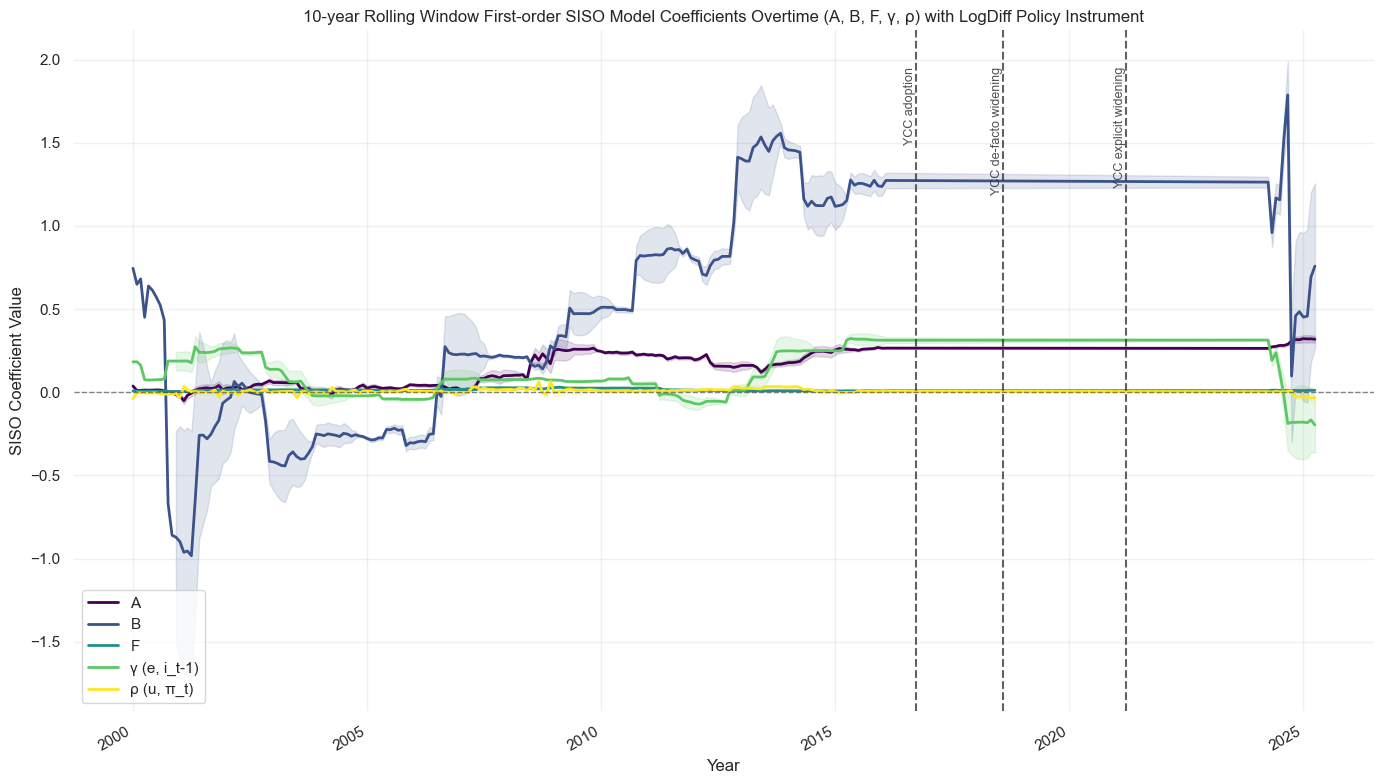

In [761]:
# Time Restricted 10-year rolling window first-order Single Input Single Output (SISO) Model Overtime Plotting with LogDiff Policy Instrument
# (!!!) 10-year rolling coefficients from SISO, same approach as we did for AR(1) Rolling Window

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
df = abf_10roll_logdiff_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 
# Time Restricted
df = df[df.index >= "2000-01-01"]

# A
A = df["A"].dropna()
# B
B = df["B"].dropna()
# F
F = df["F"].dropna()
# e_gamma (i_t-1)
e_gamma = df["e_gamma (i_t-1)"].dropna()
# u_rho (π_t)
u_rho = df["u_rho (π_t)"].dropna()

# Plotting (A, B, F, e_gamma, u_rho)
ax.plot(df.index, A, linewidth=2, 
        color="#440154", label=f"A",)
ax.fill_between(A.index, A - A.rolling(12).std(), A + A.rolling(12).std(),
                color="#440154", alpha=0.15)
ax.plot(df.index, B, linewidth=2, 
        color="#3B528B", label=f"B")
ax.fill_between(B.index, B - B.rolling(12).std(), B + B.rolling(12).std(),
                color="#3B528B", alpha=0.15)
ax.plot(df.index, F, linewidth=2, 
        color="#21908C", label=f"F")
ax.fill_between(F.index, F - F.rolling(12).std(), F + F.rolling(12).std(),
                color="#21908C", alpha=0.15)
ax.plot(df.index, e_gamma, linewidth=2, 
        color="#5DC863", label=f"γ (e, i_t-1)")
ax.fill_between(e_gamma.index, e_gamma - e_gamma.rolling(12).std(), e_gamma + e_gamma.rolling(12).std(),
                color="#5DC863", alpha=0.15)
ax.plot(df.index, u_rho, linewidth=2, 
        color="#FDE725", label=f"ρ (u, π_t)")
ax.fill_between(u_rho.index, u_rho - u_rho.rolling(12).std(), u_rho + u_rho.rolling(12).std(),
                color="#FDE725", alpha=0.15)

# Instability Regions |A+BF|>1
common_idx = A.index.intersection(B.index).intersection(F.index)
A_c = A.loc[common_idx]
B_c = B.loc[common_idx]
F_c = F.loc[common_idx]
condition = abs(A_c + B_c * F_c) > 1
in_region = False
first_span = True  
for date, val in condition.items():
    if val and not in_region:
        region_start = date
        in_region = True
    elif not val and in_region:
        if first_span:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25, label="Instability Region (|A+BF|>1)")
            first_span = False  
        else:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25)
        in_region = False
if in_region:
    ax.axvspan(region_start, common_idx[-1], color="#FF0000", alpha=0.25)


# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10-year Rolling Window First-order SISO Model Coefficients Overtime (A, B, F, γ, ρ) with LogDiff Policy Instrument")
ax.set_xlabel("Year")
ax.set_ylabel("SISO Coefficient Value")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

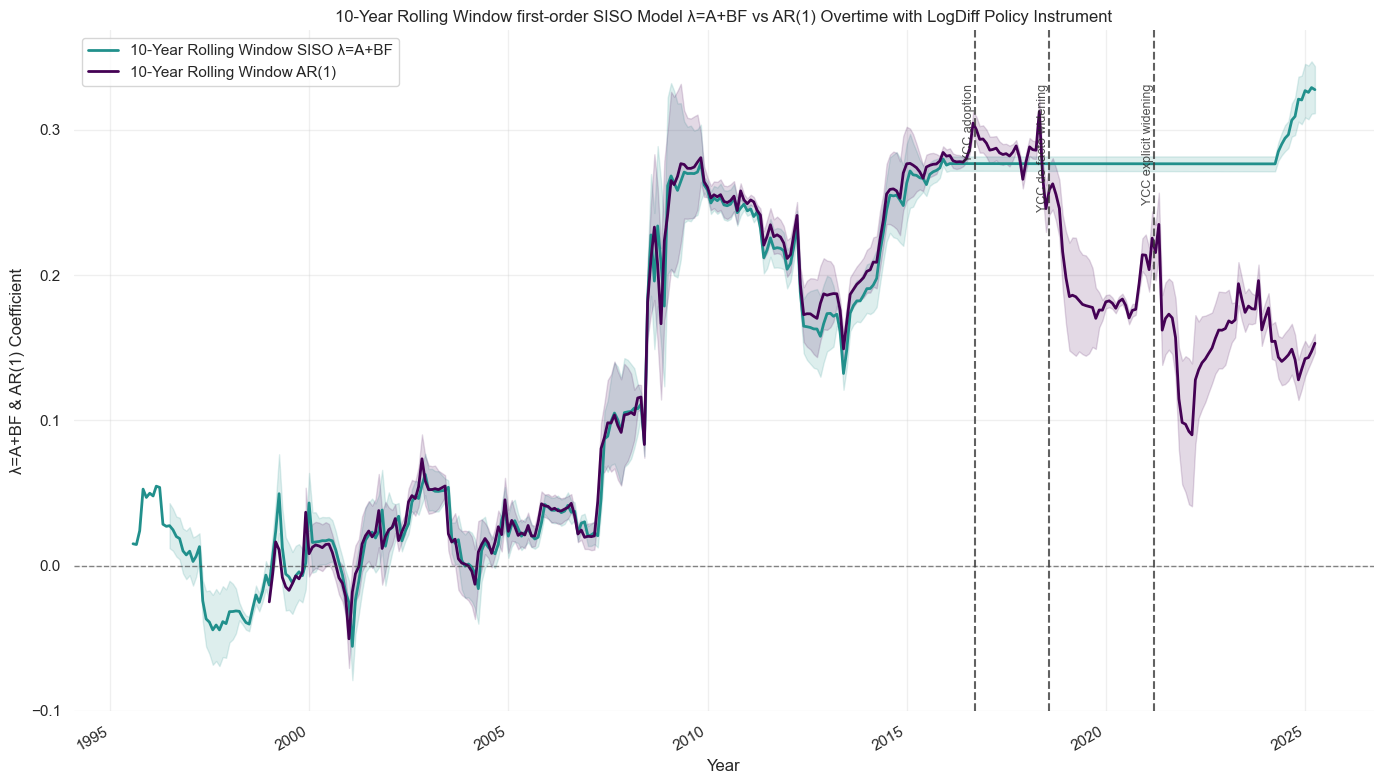

In [762]:
# 10-year rolling window first-order SISO Model Lambda vs AR(1) Overtime Plotting with LogDiff Policy Instrument
# (!!!) 10-year rolling coefficients from SISO, same approach as we did for AR(1) Rolling Window

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")


# Plotting (AR(1) & lambda)
# SISO Lambda
df = abf_10roll_logdiff_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 
# A
A = df["A"].dropna()
# B
B = df["B"].dropna()
# F
F = df["F"].dropna()
# lambda
df["lambda"] = A + B*F
lambda_SISO = df["lambda"].dropna()
ax.plot(df.index, lambda_SISO, linewidth=2, 
        color="#21908C", label=f"10-Year Rolling Window SISO λ=A+BF",)
ax.fill_between(lambda_SISO.index, lambda_SISO - lambda_SISO.rolling(12).std(), lambda_SISO + lambda_SISO.rolling(12).std(),
                color="#21908C", alpha=0.15)

# AR(1)
# (!!!) Filter date from 1990 and on, common start
df = pi_rollAR1.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 
df = df[df.index >= "1999-01-01"]
AR1 = df["LogDiff-HICP (SA)-Rolling AR(1)"].dropna()
ax.plot(df.index, AR1, linewidth=2, 
        color="#440154", label=f"10-Year Rolling Window AR(1)",)
ax.fill_between(AR1.index, AR1 - AR1.rolling(12).std(), AR1 + AR1.rolling(12).std(),
                color="#440154", alpha=0.15)




# Instability Regions |A+BF|>1
common_idx = A.index.intersection(B.index).intersection(F.index)
A_c = A.loc[common_idx]
B_c = B.loc[common_idx]
F_c = F.loc[common_idx]
condition = abs(A_c + B_c * F_c) > 1
in_region = False
first_span = True  
for date, val in condition.items():
    if val and not in_region:
        region_start = date
        in_region = True
    elif not val and in_region:
        if first_span:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25, label="Instability Region (|A+BF|>1)")
            first_span = False  
        else:
            ax.axvspan(region_start, date, color="#FF0000", alpha=0.25)
        in_region = False
if in_region:
    ax.axvspan(region_start, common_idx[-1], color="#FF0000", alpha=0.25)




# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10-Year Rolling Window first-order SISO Model λ=A+BF vs AR(1) Overtime with LogDiff Policy Instrument")
ax.set_xlabel("Year")
ax.set_ylabel("λ=A+BF & AR(1) Coefficient")
ax.grid(True, alpha=0.3)
ax.legend()
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

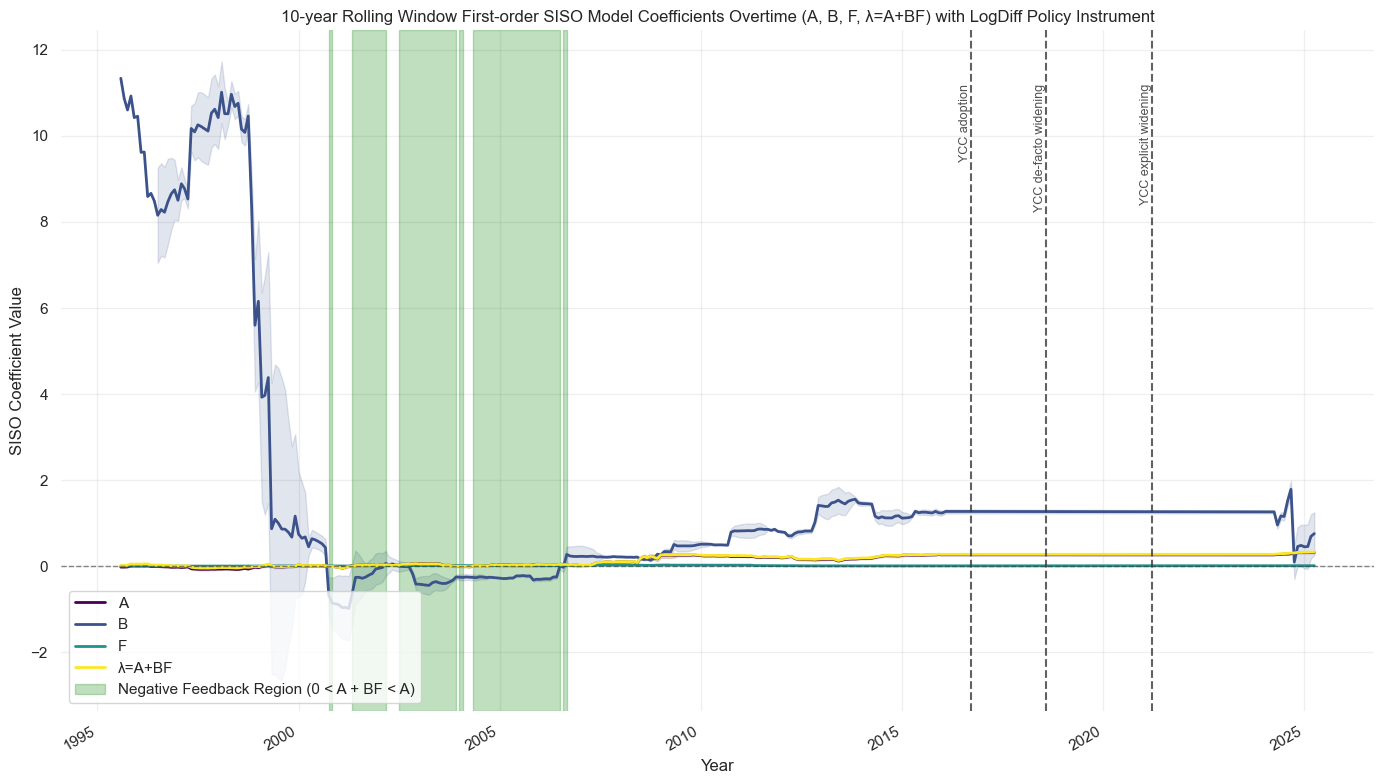

In [763]:
# 10-year rolling window first-order Single Input Single Output (SISO) Model Overtime Plotting with LogDiff Policy Instrument - Lucas Critique
# (!!!) 10-year rolling coefficients from SISO, same approach as we did for AR(1) Rolling Window

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
df = abf_10roll_logdiff_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 

# A
A = df["A"].dropna()
# B
B = df["B"].dropna()
# F
F = df["F"].dropna()
# lambda
df["lambda"] = A + B*F
lambda_SISO = df["lambda"].dropna()

# Plotting (A, B, F, e_gamma, u_rho)
ax.plot(df.index, A, linewidth=2, 
        color="#440154", label=f"A",)
ax.fill_between(A.index, A - A.rolling(12).std(), A + A.rolling(12).std(),
                color="#440154", alpha=0.15)
ax.plot(df.index, B, linewidth=2, 
        color="#3B528B", label=f"B")
ax.fill_between(B.index, B - B.rolling(12).std(), B + B.rolling(12).std(),
                color="#3B528B", alpha=0.15)
ax.plot(df.index, F, linewidth=2, 
        color="#21908C", label=f"F")
ax.fill_between(F.index, F - F.rolling(12).std(), F + F.rolling(12).std(),
                color="#21908C", alpha=0.15)
ax.plot(df.index, lambda_SISO, linewidth=2, 
        color="#FDE725", label=f"λ=A+BF",)
ax.fill_between(lambda_SISO.index, lambda_SISO - lambda_SISO.rolling(12).std(), lambda_SISO + lambda_SISO.rolling(12).std(),
                color="#FDE725", alpha=0.15)

# Negative Feedback Regions (0 < A + BF < A)
common_idx = A.index.intersection(B.index).intersection(F.index)
A_c = A.loc[common_idx]
B_c = B.loc[common_idx]
F_c = F.loc[common_idx]
condition = (0 < A_c + B_c * F_c) & (A_c + B_c * F_c < A_c)
in_region = False
first_span = True  
for date, val in condition.items():
    if val and not in_region:
        region_start = date
        in_region = True
    elif not val and in_region:
        if first_span:
            ax.axvspan(region_start, date, color="green", alpha=0.25, label="Negative Feedback Region (0 < A + BF < A)")
            first_span = False  
        else:
            ax.axvspan(region_start, date, color="green", alpha=0.25)
        in_region = False
if in_region:
    ax.axvspan(region_start, common_idx[-1], color="green", alpha=0.25)


# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("10-year Rolling Window First-order SISO Model Coefficients Overtime (A, B, F, λ=A+BF) with LogDiff Policy Instrument")
ax.set_xlabel("Year")
ax.set_ylabel("SISO Coefficient Value")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### **17) LONGEST PERIOD SINGLE ESTIMATE**

In [764]:
# Longest period single estimate - Descriptive Statistics Decomposition
# (!!!) we just need to express the values of A, B, F from the descriptive statistics, we go back to levels instead of logdiff for policy instrument
# (!!!) π_{t+1} = A π_t + B i_t + u 
# (!!!) i_t = F π_t + v 
# (!!!) π_{t+1} = λ_π π_t + w

df = jp_core_hybrid_df[["LogDiff-HICP (SA)", "Call Money/Interbank Immediate (%)"]].dropna().copy()
df.columns = ["pi", "i"]

# Time Allignment
# (!!!) We keep pi and i as before
# (!!!) Time allignment necessary, without r crashes 
# pi_t
pi_t   = df["pi"].iloc[:-1].values
# pi_t+1
pi_t1  = df["pi"].iloc[1:].values  
# i_t    
i_t    = df["i"].iloc[:-1].values
aligned = pd.DataFrame({"pi_t": pi_t, "pi_t1": pi_t1, "i_t": i_t}).dropna()
pi_t  = aligned["pi_t"]
pi_t1 = aligned["pi_t1"]
i_t   = aligned["i_t"]

# Correlation (r)
# pi_t+1 and pi_t
r_pit1_pit = pi_t1.corr(pi_t)  
# pi_t+1 and i_t         
r_pit1_it = pi_t1.corr(i_t) 
# i_t and pi_t         
r_it_pit = i_t.corr(pi_t)         

# Standard Deviation (s)
s_pit1 = pi_t1.std()                    
s_pit  = pi_t.std()                     
s_it = i_t.std()                       

# Trivariate Regression
# (!!!) Better to specify the denominator common between all 
denom = 1 - r_it_pit**2

# A (pi_t)
A = ((r_pit1_pit - r_pit1_it * r_it_pit) / denom) * (s_pit1 / s_pit)
# B (i_t)
B = ((r_pit1_it - r_pit1_pit * r_it_pit) / denom) * (s_pit1 / s_it)
# F (i_t on pi_t)
# (!!!) To change the denominator
F = r_it_pit * (s_it / s_pit)

# Lambda (A+BF)
# (!!!) We calculate it this time through the equations, not through the classic A+BF
lambda_ar = r_pit1_pit * (s_pit1 / s_pit)

# Descriptive Statistics
descriptive_statistics = pd.DataFrame({
    "Descriptive Statistics": ["r(π_{t+1}, π_t)", "r(π_{t+1}, i_t)", "r(i_t, π_t)",
                  "σ(π_{t+1})", "σ(π_t)", "σ(i_t)",
                  "A", "B", "F", "λ_π", "A + BF"],
    "Value": [r_pit1_pit, r_pit1_it, r_it_pit,
              s_pit1, s_pit, s_it,
              A, B, F, lambda_ar, A + B * F]
}).round(4)

descriptive_statistics

,Descriptive Statistics,Value
0,"r(π_{t+1}, π_t)",0.1645
1,"r(π_{t+1}, i_t)",0.1938
2,"r(i_t, π_t)",0.1988
3,σ(π_{t+1}),3.2164
4,σ(π_t),3.2157
5,σ(i_t),2.0100
6,A,0.1312
7,B,0.2685
8,F,0.1243
9,λ_π,0.1645


In [765]:
# 10-Year Rolling window estimates of r(π_t, i_t), σ_π/σ_i, and F̂_π
# (!!!) F_π = r(i_t, π_t) * σ_i/σ_π  >1  which leads to 0 < σ_π/σ_i < r(i_t, π_t) < 1

df = jp_core_hybrid_df.drop(columns="10-Year Gov Bond Yields (%)").dropna().copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 
df = df.rename(columns={
    "LogDiff-HICP (SA)": "pi",
    "Call Money/Interbank Immediate (%)": "i"
})

# Rolling window (like usual)
# (!!!) 10 years = 120 months
window = 120
rows = []

# Rolling statistics
for start in range(window, len(df)):
    chunk = df.iloc[start - window:start]
# Inflation
    pi_c = chunk["pi"]
# Policy Instrument
    i_c  = chunk["i"]

# Correlation (r)
    r = pi_c.corr(i_c)
# Standard Deviation (s)
# (!!!) For both inflation and policy instrument
    s_pi = pi_c.std()
    s_i = i_c.std()
# Ratio of standard deviations (s-pi/s_i)
    ratio_s = s_pi / s_i
# F (empirically computed)
# (!!!) F_π = r(i_t, π_t) * σ_i/σ_π                 
    F_hat = r * (s_i / s_pi)            

    rows.append({"Time": df.index[start], "r": r, "Sigma Ratio": ratio_s, "F_hat": F_hat})

stats_rolling10 = pd.DataFrame(rows).set_index("Time")
stats_rolling10

,r,Sigma Ratio,F_hat
Time,,,
1999-01-01,0.243299,1.348097,0.180476
1999-02-01,0.256738,1.364047,0.188218
1999-03-01,0.270329,1.350768,0.200130
1999-04-01,0.275215,1.347366,0.204262
1999-05-01,0.271681,1.279251,0.212375
...,...,...,...
2024-12-01,0.109015,50.200979,0.002172
2025-01-01,0.142774,48.060042,0.002971
2025-02-01,0.136354,44.535172,0.003062


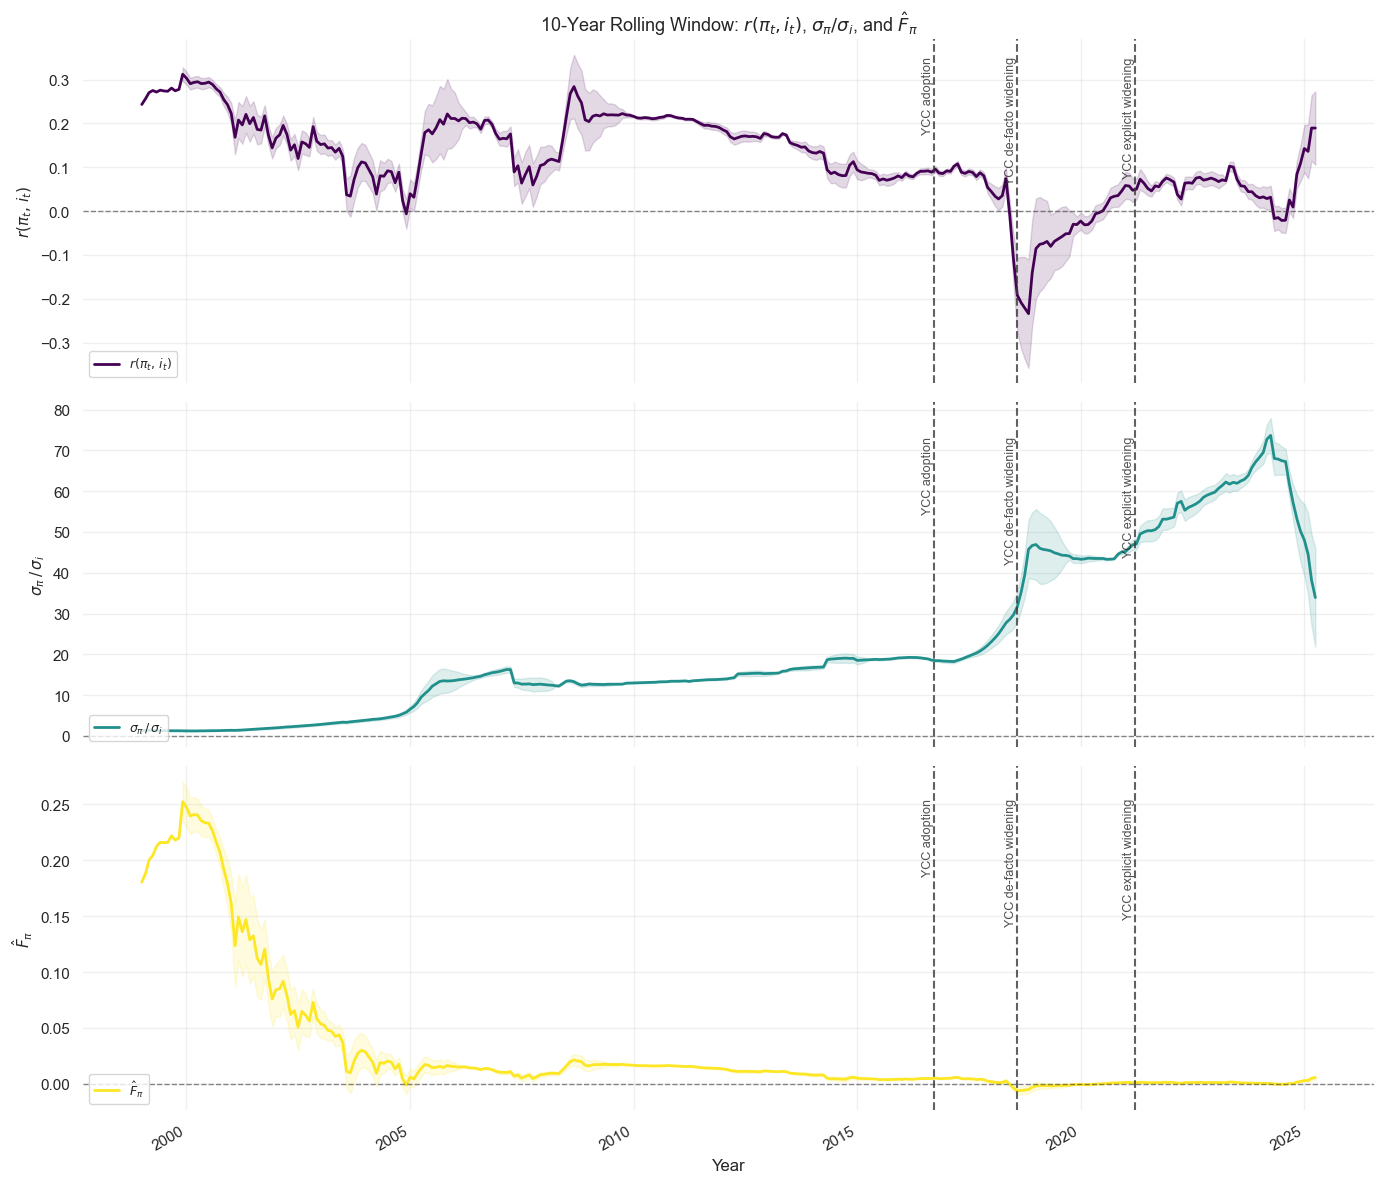

In [766]:
# 10-year rolling window estimates of r(π_t, i_t), σ_π/σ_i, and F̂_π overtime plotting

# (!!!) Same cosmetics but splitted on 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor="white", sharex=True)
df = stats_rolling10.copy()
df.index = pd.to_datetime(df.index)

# r(π_t, i_t)
r = df["r"].dropna()
# σ_π / σ_i
sigma_ratio = df["Sigma Ratio"].dropna()
# F̂_π
F_hat = df["F_hat"].dropna()

# General Settings
# Series and subplot config
series_cfg = [
    (r,"#440154", r"$r(\pi_t,\, i_t)$", None),
    (sigma_ratio, "#21908C", r"$\sigma_\pi\,/\,\sigma_i$",  None),
    (F_hat, "#FDE725", r"$\hat{F}_\pi$", 1.0),
]
ycc_lines = [
    (pd.Timestamp("2016-09-21"), "YCC adoption"),
    (pd.Timestamp("2018-07-31"), "YCC de-facto widening"),
    (pd.Timestamp("2021-03-19"), "YCC explicit widening"),
]

# Subplots loop build
for ax, (series, color, label, threshold) in zip(axes, series_cfg):
    ax.plot(series.index, series, linewidth=2, color=color, label=label)
    ax.fill_between(series.index,
                    series - series.rolling(12).std(),
                    series + series.rolling(12).std(),
                    color=color, alpha=0.15)
# YCC reference lines on every subplot
    for vdate, vtext in ycc_lines:
        ax.axvline(vdate, color="#393939", lw=1.5, ls="--", alpha=0.8)
        ax.text(vdate, ax.get_ylim()[1] * 0.9, vtext,
                rotation=90, va="top", ha="right", fontsize=9, alpha=0.8)

# Cosmetics 
# (!!!) Subplot dependent settings 
    ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)
    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
# (!!!) General settings applying to the entire fig
axes[0].set_title(r"10-Year Rolling Window: $r(\pi_t, i_t)$, $\sigma_\pi/\sigma_i$, and $\hat{F}_\pi$",
                  fontsize=13)
axes[-1].set_xlabel("Year")
axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### **18) INDIRECT LEAST SQUARE ESTIMATION**

In [767]:
# Indirect Least Squares (ILS) with Simultaneous Equations
# (!!!) The end of this is what I forgot at the end of the exam in the demostration of the law of motion
# (!!!) Structural system (S1): π_t = B*i_t + G*y_t + O*z_t + ε_t, i_t = F*π_t + 0*y_t + H*z_t + η_t
# (!!!) Reduced form (SR): π_t = β_πy*y_t + β_πz*z_t + ε_R,t i_t = β_iy*y_t + β_iz*z_t + η_R,t
# (!!!) ILS:  F = β_iy/β_πy  and  B = β_πz/β_iz
# Instruments import (transformed)
df_instruments = jp_trans_df[["Time", 
                    "HPfilter-Real GDP (billions chained 2015 JPY)",   
                    "LogDiff-Total Treasury Reserves (- Gold)"
                    ]].copy()
df_core = jp_core_hybrid_df.dropna().copy()
df = pd.merge(df_core, df_instruments, on="Time", how="outer")
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")

# Inflation
pi = df["LogDiff-HICP (SA)"]
# Policy Instrument
i = df["Call Money/Interbank Immediate (%)"]


# Instrumental Variable (for policy) 
# Output Gap (y)                                
y = df["HPfilter-Real GDP (billions chained 2015 JPY)"]        
# Treasury Reserves (z)
z = df["LogDiff-Total Treasury Reserves (- Gold)"]

# (!!!) Variables Alligment to common index
alligned_df = pd.concat([pi, i, y, z], axis=1).dropna()
alligned_df.columns = ["pi", "i", "y", "z"]
# (!!!) all stands for alligned
pi_all = alligned_df["pi"]
i_all  = alligned_df["i"]
y_all  = alligned_df["y"]
z_all  = alligned_df["z"]

# Reduced Form Estimation (SR) 
X_rf = sm.add_constant(pd.concat([y_all, z_all], axis=1))


# Reduced form equation 1: π_t = sum of β*X for each instrument
rf_pi  = sm.OLS(pi_all, X_rf).fit()
# beta pi and y
b_pi_y = rf_pi.params["y"]
# beta pi and z      
b_pi_z = rf_pi.params["z"]       

# Reduced form equation 2: i_t = β_iy·y_t + β_iz·z_t
rf_i = sm.OLS(i_all, X_rf).fit()
# beta i and y
b_i_y = rf_i.params["y"]
# beta i and z      
b_i_z = rf_i.params["z"]       

# ILS Recovery 
# (!!!) F = β_iy / β_πy (feedback rule slope)
F_hat_ils = b_i_y / b_pi_y
# (!!!) B̂ = β_πz/ β_iz (policy instrument slope in inflation)
B_hat_ils = b_pi_z / b_i_z

print(rf_pi.summary())
print(rf_i.summary())

                            OLS Regression Results                            
Dep. Variable:                     pi   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     6.205
Date:                Sat, 21 Mar 2026   Prob (F-statistic):            0.00223
Time:                        07:51:01   Log-Likelihood:                -947.62
No. Observations:                 376   AIC:                             1901.
Df Residuals:                     373   BIC:                             1913.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6431      0.164      3.912      0.0

In [768]:
# Structural Parameters
ils_structural_params = pd.DataFrame({
    "Structural Parameter": ["β_πy", "β_πz", "β_iy", "β_iz", "F̂ = β_iy/β_πy", "B̂ = β_πz/β_iz"],
    "Value": [b_pi_y, b_pi_z, b_i_y, b_i_z, F_hat_ils, B_hat_ils]
}).round(4)
ils_structural_params

,Structural Parameter,Value
0,β_πy,36.5994
1,β_πz,-22.1293
2,β_iy,1.3525
3,β_iz,5.0135
4,F̂ = β_iy/β_πy,0.0370
5,B̂ = β_πz/β_iz,-4.4139


In [776]:
# Top Performing Instruments Combinations for R^2 Maximization (Global R^2, R_π^2, R_i^2)
# (!!!) From jp_trans_df we have to exclude the transformed version of the policy target and instrument
df_all_instruments = jp_trans_df.drop(columns=["AR(1)detrend-Call Money/Interbank Immediate (%)", "LogDiff-Call Money/Interbank Immediate (%)"]).copy()
df_all_instruments["Time"] = pd.to_datetime(df_all_instruments["Time"])
df_all_instruments = df_all_instruments.set_index("Time")

# (!!!) Drop columns that are pi or i 
exclude = ["LogDiff-HICP (SA)", "Call Money/Interbank Immediate (%)",
           "Country", "index"]
candidate_cols = [c for c in df_all_instruments.columns
                  if c not in exclude and pd.api.types.is_numeric_dtype(df_all_instruments[c])]

# (!!!) Date Allignment with pi and i
base = pd.concat([pi, i, df_all_instruments[candidate_cols]], axis=1).dropna()
pi_s = base["LogDiff-HICP (SA)"]
i_s  = base["Call Money/Interbank Immediate (%)"]
instr_pool = base[candidate_cols]

# Search Loop
# (!!!) Search over combinations of size 1 and 2 only
results_search = []
for size in range(1, 3):
    for combo in combinations(candidate_cols, size):
        X = sm.add_constant(instr_pool[list(combo)])
# (!!!) Iteration and testing on both the equations
        r2_pi = sm.OLS(pi_s, X).fit().rsquared
        r2_i  = sm.OLS(i_s,  X).fit().rsquared
        results_search.append({
            "Instruments": combo,
            "Number of instruments": size,
            "R2_pi": round(r2_pi, 4),
            "R2_i":  round(r2_i, 4),
# (!!!) Global score: sum of both R² to find best joint fit
            "R2_global": round(r2_pi + r2_i, 4)
        })

combo_inst_search_df = pd.DataFrame(results_search).sort_values("R2_global", ascending=False)

# Global
print("Top 10 Instrument Combinations (R2_pi + R2_i)")
print(combo_inst_search_df.head(10).to_string(index=False))
# pi_t
print("Top 10 for π_t")
print(combo_inst_search_df.sort_values("R2_pi", ascending=False).head(10).to_string(index=False))
# i_t
print("Top 10 for i_t")
print(combo_inst_search_df.sort_values("R2_i", ascending=False).head(10).to_string(index=False))

Top 10 Instrument Combinations (R2_pi + R2_i)
                                                                                     Instruments  Number of instruments  R2_pi   R2_i  R2_global
         (LogDiff-Monetary Aggregates - M1 (JPY), HPfilter-Real GDP (billions chained 2015 JPY))                      2 0.0318 0.4369     0.4687
             (LogDiff-Monetary Aggregates - M1 (JPY), AR(1)detrend-10-Year US T-Bills Yield (%))                      2 0.0460 0.3492     0.3952
                (LogDiff-Monetary Aggregates - M1 (JPY), AR(1)detrend-Deposit Interest Rate (%))                      2 0.0195 0.3718     0.3913
                                 (LogDiff-Monetary Aggregates - M1 (JPY), AR(1)detrend-CBOE-VIX)                      2 0.0043 0.3852     0.3895
 (LogDiff-Monetary Aggregates - M1 (JPY), AR(1)detrend-Total Credit - General Government (%GDP))                      2 0.0388 0.3495     0.3883
                                  (LogDiff-Monetary Aggregates - M1 (JPY), LogDiff-1

### **19) ROLLING REGRESSION WITH 6 QUARTER LAGS**

In [781]:
# 6-Quarter Lag Policy Instrument 10-Years Rolling Window SISO Regression 
# (!!) 6Q = 18 months in monthly frequency and each lag is here considered in quarter terms
# (!!!) π_{t+1} = A π_{t-1} + B i_{t-6} + u_{t+1} with u_{t+1} = ρu_t + ε_{t+1}
# (!!!) i_t = F π_t + u_{t+1} with  u_{t+1} = ρu_t + ε_{t+1}

df = jp_core_hybrid_df[["Time", "LogDiff-HICP (SA)", "Call Money/Interbank Immediate (%)"]].dropna().copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time")
df.columns = ["pi", "i"]

# Lag & Window
# (!!!) 2 different types of lag/lead, one for pi and one for i
lead_pi = -3
lag_pi = 3
lag_i = 18
window = 120
# Lagged Variables
# π_t+1
pi_lead1 = df["pi"].shift(lead_pi)
# π_t-1     
pi_lag1 = df["pi"].shift(lag_pi)  
# i_t-6
i_lag6 = df["i"].shift(lag_i)    

# Date Allignment
aligned = pd.concat([pi_lead1, pi_lag1, i_lag6, df["pi"], df["i"]], axis=1).dropna()
aligned.columns = ["pi_t1", "pi_tm1", "i_tm6", "pi_t", "i_t"]

results = []

# Rolling Window SISO Set Up
# (!!!) Like we did before, just with different lag
for start in range(window, len(aligned)):
    chunk = aligned.iloc[start - window:start]
# SISO Equation 1: π_{t+1} = A π_{t-1} + B i_{t-6Q} 
# (!!!) exactly like the first time with AR(1) on u_rho
    X1 = sm.add_constant(chunk[["pi_tm1", "i_tm6"]])
    m1 = sm.OLS(chunk["pi_t1"], X1).fit()
    A = m1.params["pi_tm1"]
    B = m1.params["i_tm6"]
    u_rho = m1.resid.autocorr(lag=1)
# SISO Equation 2: i_t = F π_t + u 
    X2 = sm.add_constant(chunk[["pi_t"]])
    m2 = sm.OLS(chunk["i_t"], X2).fit()
    F = m2.params["pi_t"]
    e_gamma = m2.resid.autocorr(lag=1)
# Combined Results
    results.append({
        "Time": aligned.index[start],
        "A": A, "B": B, "F": F,
        "e_gamma (i_t)": e_gamma,
        "u_rho (π_t+1)": u_rho
    })

results_6qlag_df = pd.DataFrame(results).round(4)
results_6qlag_df

,Time,A,B,F,e_gamma (i_t),u_rho (π_t+1)
0,2000-07-01,0.0541,0.2067,0.2331,0.9008,-0.0565
1,2000-08-01,0.0464,0.2108,0.2262,0.9044,-0.0595
2,2000-09-01,0.0433,0.2040,0.2161,0.9103,-0.0680
3,2000-10-01,0.0420,0.1936,0.2071,0.9149,-0.0968
4,2000-11-01,0.0272,0.1809,0.1917,0.9246,-0.0555
...,...,...,...,...,...,...
290,2024-09-01,0.2897,-4.1816,0.0004,0.9123,0.0689
291,2024-10-01,0.2982,-4.0603,0.0002,0.9266,0.0709
292,2024-11-01,0.2974,-4.1939,0.0016,0.9290,0.0717
293,2024-12-01,0.3068,-4.1705,0.0022,0.9315,0.0720


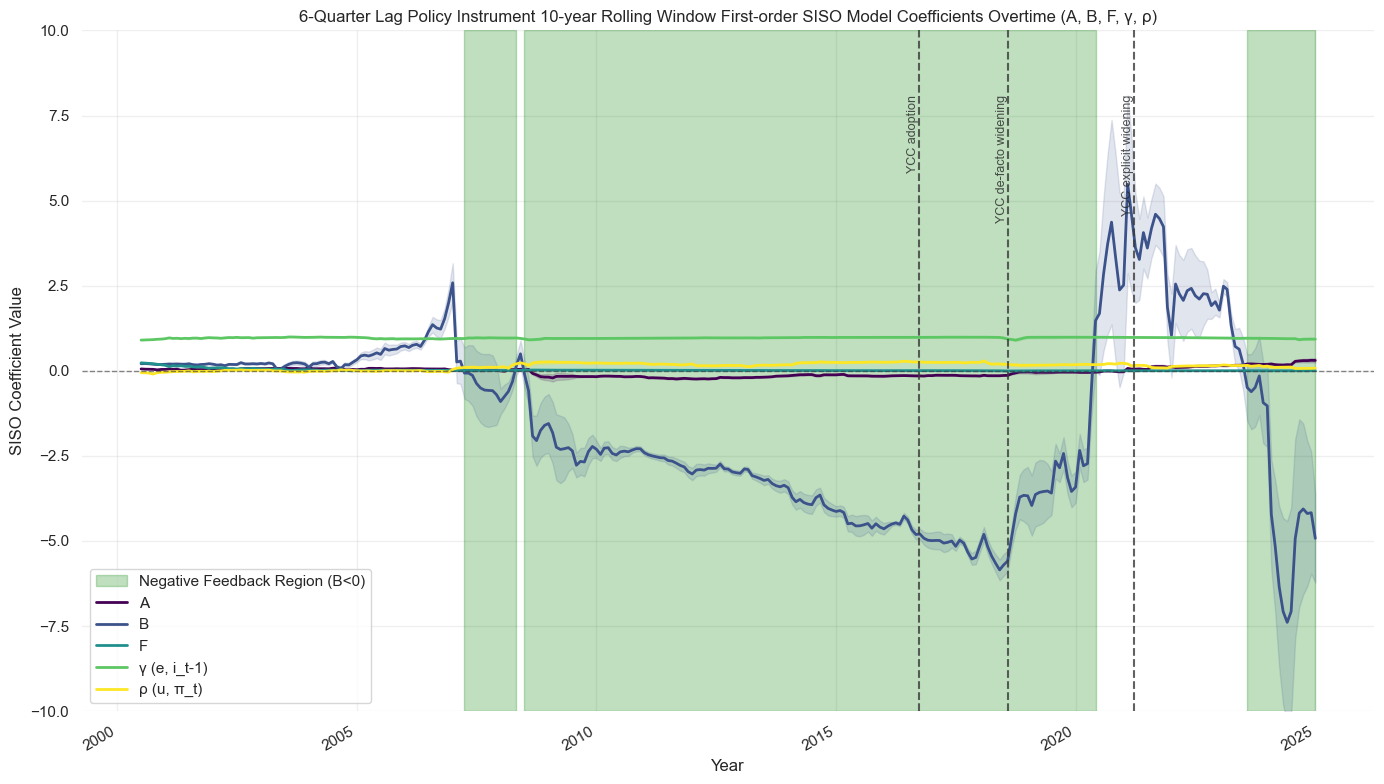

In [ ]:
# 6-Quarter Lag Policy Instrument 10-Years Rolling Window SISO Regression Overtime Plotting
# (!!!) 10-year rolling coefficients from SISO, same approach as we did for AR(1) Rolling Window

fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
df = results_6qlag_df.copy()
df["Time"] = pd.to_datetime(df["Time"])
df = df.set_index("Time") 

# A
A = df["A"].dropna()
# B
B = df["B"].dropna()
# F
F = df["F"].dropna()
# e_gamma (i_t-1)
e_gamma = df["e_gamma (i_t)"].dropna()
# u_rho (π_t)
u_rho = df["u_rho (π_t+1)"].dropna()


# Plotting (A, B, F, e_gamma, u_rho)
ax.plot(df.index, A, linewidth=2, 
        color="#440154", label=f"A",)
ax.fill_between(A.index, A - A.rolling(12).std(), A + A.rolling(12).std(),
                color="#440154", alpha=0.15)
ax.plot(df.index, B, linewidth=2, 
        color="#3B528B", label=f"B")
ax.fill_between(B.index, B - B.rolling(12).std(), B + B.rolling(12).std(),
                color="#3B528B", alpha=0.15)
ax.plot(df.index, F, linewidth=2, 
        color="#21908C", label=f"F")
ax.fill_between(F.index, F - F.rolling(12).std(), F + F.rolling(12).std(),
                color="#21908C", alpha=0.15)
ax.plot(df.index, e_gamma, linewidth=2, 
        color="#5DC863", label=f"γ (e, i_t-1)")
ax.fill_between(e_gamma.index, e_gamma - e_gamma.rolling(12).std(), e_gamma + e_gamma.rolling(12).std(),
                color="#5DC863", alpha=0.15)
ax.plot(df.index, u_rho, linewidth=2, 
        color="#FDE725", label=f"ρ (u, π_t)")
ax.fill_between(u_rho.index, u_rho - u_rho.rolling(12).std(), u_rho + u_rho.rolling(12).std(),
                color="#FDE725", alpha=0.15)

# Negative Feedback Regions (B<0)
common_idx = A.index.intersection(B.index).intersection(F.index)
A_c = A.loc[common_idx]
B_c = B.loc[common_idx]
F_c = F.loc[common_idx]
condition = B_c < 0
in_region = False
first_span = True  
for date, val in condition.items():
    if val and not in_region:
        region_start = date
        in_region = True
    elif not val and in_region:
        if first_span:
            ax.axvspan(region_start, date, color="green", alpha=0.25, label="Negative Feedback Region (B<0)")
            first_span = False  
        else:
            ax.axvspan(region_start, date, color="green", alpha=0.25)
        in_region = False
if in_region:
    ax.axvspan(region_start, common_idx[-1], color="green", alpha=0.25)


# YCC reference lines (your style)
# Reference vertical lines with respect to YCC adoption dates 
# YCC Adoption Line (2016-09-21)
ycc_date = pd.Timestamp("2016-09-21")
ax.axvline(
    ycc_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    ycc_date,
    ax.get_ylim()[1]*0.9,
    "YCC adoption",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC De-facto Widening Line (2016-09-21)
defacto_widen_date = pd.Timestamp("2018-07-31")
ax.axvline(
    defacto_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    defacto_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC de-facto widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)
# YCC Explicit Widening Line (2016-09-21)
explicit_widen_date = pd.Timestamp("2021-03-19")
ax.axvline(
    explicit_widen_date,
    color="#393939",
    lw=1.5,
    ls="--",
    alpha=0.8,
)
ax.text(
    explicit_widen_date,
    ax.get_ylim()[1]*0.9,
    "YCC explicit widening",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("6-Quarter Lag Policy Instrument 10-year Rolling Window First-order SISO Model Coefficients Overtime (A, B, F, γ, ρ)")
ax.set_xlabel("Year")
ax.set_ylabel("SISO Coefficient Value")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax.axhline(0, color="#393939", lw=1, ls="--", alpha=0.6)
# Rescailing
ax.set_ylim(-10, 10)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()